In [2]:
import os
import pathlib

import warnings
warnings.filterwarnings("ignore")

import FunctionLib as FL
from tqdm import tqdm

import numpy as np
import pandas as pd
import scipy
from scipy.interpolate import interp1d

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
config = {
    "font.size": 18,
    "font.family": "serif",
    "figure.figsize": (25, 14),

    "axes.titlesize": 28,        # ax.set_title fontsize
    "axes.labelsize": 24,        # ax.set_xlabel/ylabel fontsize
    "legend.fontsize": 20,       # ax.legend fontsize
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 2,         # 对应 ax.spines...linewidth
    "axes.edgecolor": "black",   # 对应 ax.spines...color

    "xtick.direction": "in",     # direction='in'
    "ytick.direction": "in",
    "xtick.top": True,           # ax.xaxis.set_ticks_position('both')
    "ytick.right": True,         # ax.yaxis.set_ticks_position('both')

    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "xtick.minor.width": 2,      # which='both' implies minor too
    "ytick.minor.width": 2,

    "xtick.major.size": 6,       # length=6 major
    "ytick.major.size": 6,
    "xtick.minor.size": 3,       # length=3 minor
    "ytick.minor.size": 3,
}
mpl.rcParams.update(config)

import astropy
import astropy.units as u

DJAv4Catalog = FL.Spectrum_Catalog()
DJAv4Catalog.load_from_pkl(('./DJAV4.2Catalog.pkl'))
print(DJAv4Catalog.sample_num())
DJAv4Catalog.to_dataframe()

1102


,survey_id_subid,prism_filepath,prism_redshift,determined_redshift,grating_filepaths,grating_redshifts,file_count,available_filters,properties,survey_id,sample_flag,reason_for_exclusion,grating_within_coverage,grating_slitloss_correction,lines_fit,line_ratios,dust_curve_parameters
0,snh0pe-v4_4446_102,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.2259,0.2259,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': nan, 'g235m-f170lp': nan}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
1,snh0pe-v4_4446_143,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.6318,1.6311,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.6313, 'g235m-f170lp': 1.6309}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
2,snh0pe-v4_4446_285,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,0.4446,0.4462,{'g235m-f170lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g235m-f170lp': 0.4462, 'g140m-f100lp': 0.4462}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
3,snh0pe-v4_4446_29,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7834,1.77975,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7799, 'g235m-f170lp': 1.7796}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
4,snh0pe-v4_4446_123,/home/xingyaocai/DJAv4.2/snh0pe-v4/snh0pe-v4_p...,1.7855,1.7855,{'g140m-f100lp': '/home/xingyaocai/DJAv4.2/snh...,"{'g140m-f100lp': 1.7855, 'g235m-f170lp': 1.7851}",3,"{g235m-f170lp, prism-clear, g140m-f100lp}",{'redshift_conflict': False},snh0pe-v4,False,"[redshift_below_3, redshift_below_3]",{},{},{},{},{}
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43037,glimpse-obs02-v4_9223_9152,None,None,5.5385,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 5.5385},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43038,glimpse-obs02-v4_9223_98001,None,None,2.6322,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 2.6322},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}
43039,glimpse-obs02-v4_9223_47046,None,None,4.3554,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 4.3554},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,[no_prism_spectrum],{},{},{},{},{}
43040,glimpse-obs02-v4_9223_45350,None,None,1.3675,{'g395m-f290lp': '/home/xingyaocai/DJAv4.2/gli...,{'g395m-f290lp': 1.3675},1,{g395m-f290lp},{'redshift_conflict': False},glimpse-obs02-v4,False,"[redshift_below_3, no_prism_spectrum]",{},{},{},{},{}


In [3]:
group_conditions = [(-0.05,0.02),(0.02,0.10), (0.10,0.2),(0.2,0.3),(0.3,0.40),(0.40,0.6)]

def group_condition_func(balmer_decrement):
    for i, (low, high) in enumerate(group_conditions):
        if low < balmer_decrement <= high:
            return i
    return 6

In [4]:
group0_averager=FL.SpectrumAverager()
group1_averager=FL.SpectrumAverager()
group2_averager=FL.SpectrumAverager()
group3_averager=FL.SpectrumAverager()
group4_averager=FL.SpectrumAverager()
group5_averager=FL.SpectrumAverager()
group6_averager=FL.SpectrumAverager()


for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
    if not catalog['sample_flag']:
        continue

    uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
    halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
    hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
    balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
    group_index=group_condition_func(balmer_decrement)
    if group_index==-1:
        continue

    averager_to_use='group'+str(group_index)+'_averager'
    globals()[averager_to_use].load_spectrum_catalog([surveyid_subid],DJAv4Catalog)

for i in range(7):
    averager_to_use='group'+str(i)+'_averager'
    globals()[averager_to_use].create_common_wavelength_grid(wavelength_range=(1350,8000),grid_size=10)
    globals()[averager_to_use].interpolate_spectra(interpolation_method='linear')
    globals()[averager_to_use].spectrum_normalization_within_range(wavelength_range=(5400,5600),target_flux=1.e-19)
    globals()[averager_to_use].compute_average_spectrum(method='median', ignore_nan=True, use_percentile_filter=True, lower_percentile=5, upper_percentile=95)

Spectrum index 41 has invalid normalization factor. Skipping.


In [5]:
group_decrement_list=[]

for i in range(6):
    decrement_list=[]

    for surveyid_subid, catalog in DJAv4Catalog.catalog_iterator():
        if not catalog['sample_flag']:
            continue

        uv_slope_value=catalog['dust_curve_parameters']['UV_Continuum_Fitting_Parameters']['exponent']
        halpha_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['halpha_flux']
        hbeta_flux=catalog['dust_curve_parameters']['Best_Balmer_Decrement_Line_Parameters']['hbeta_flux']
        balmer_decrement=np.log(halpha_flux/hbeta_flux/2.86)
        group_index=group_condition_func(balmer_decrement)
        if group_index!=i:
            continue
        if group_index==-1:
            continue

        decrement_list.append(balmer_decrement)

    group_decrement_list.append(np.mean(decrement_list))

In [6]:
group_decrement_list[0]=0
group_decrement_list

[0,
 np.float64(0.06204199540297288),
 np.float64(0.1468996563812721),
 np.float64(0.24619297697293827),
 np.float64(0.34784501292857684),
 np.float64(0.49922688741835725)]

In [7]:
model_spectra=group0_averager.average_flux*u.erg/u.s/u.cm**2/u.AA
tau_lambda_list=[]
Q_lambda_list=[]

for i in range(1,6):
    averager_to_use='group'+str(i)+'_averager'
    tau_lambda_list=[]
    groupi_averager=globals()[averager_to_use]
    tau_lambda=-np.log( (groupi_averager.average_flux)/(group0_averager.average_flux) )
    tau_lambda_list.append(tau_lambda)
    Q_lambda=tau_lambda/ (group_decrement_list[i]-group_decrement_list[0])
    Q_lambda_list.append(Q_lambda)

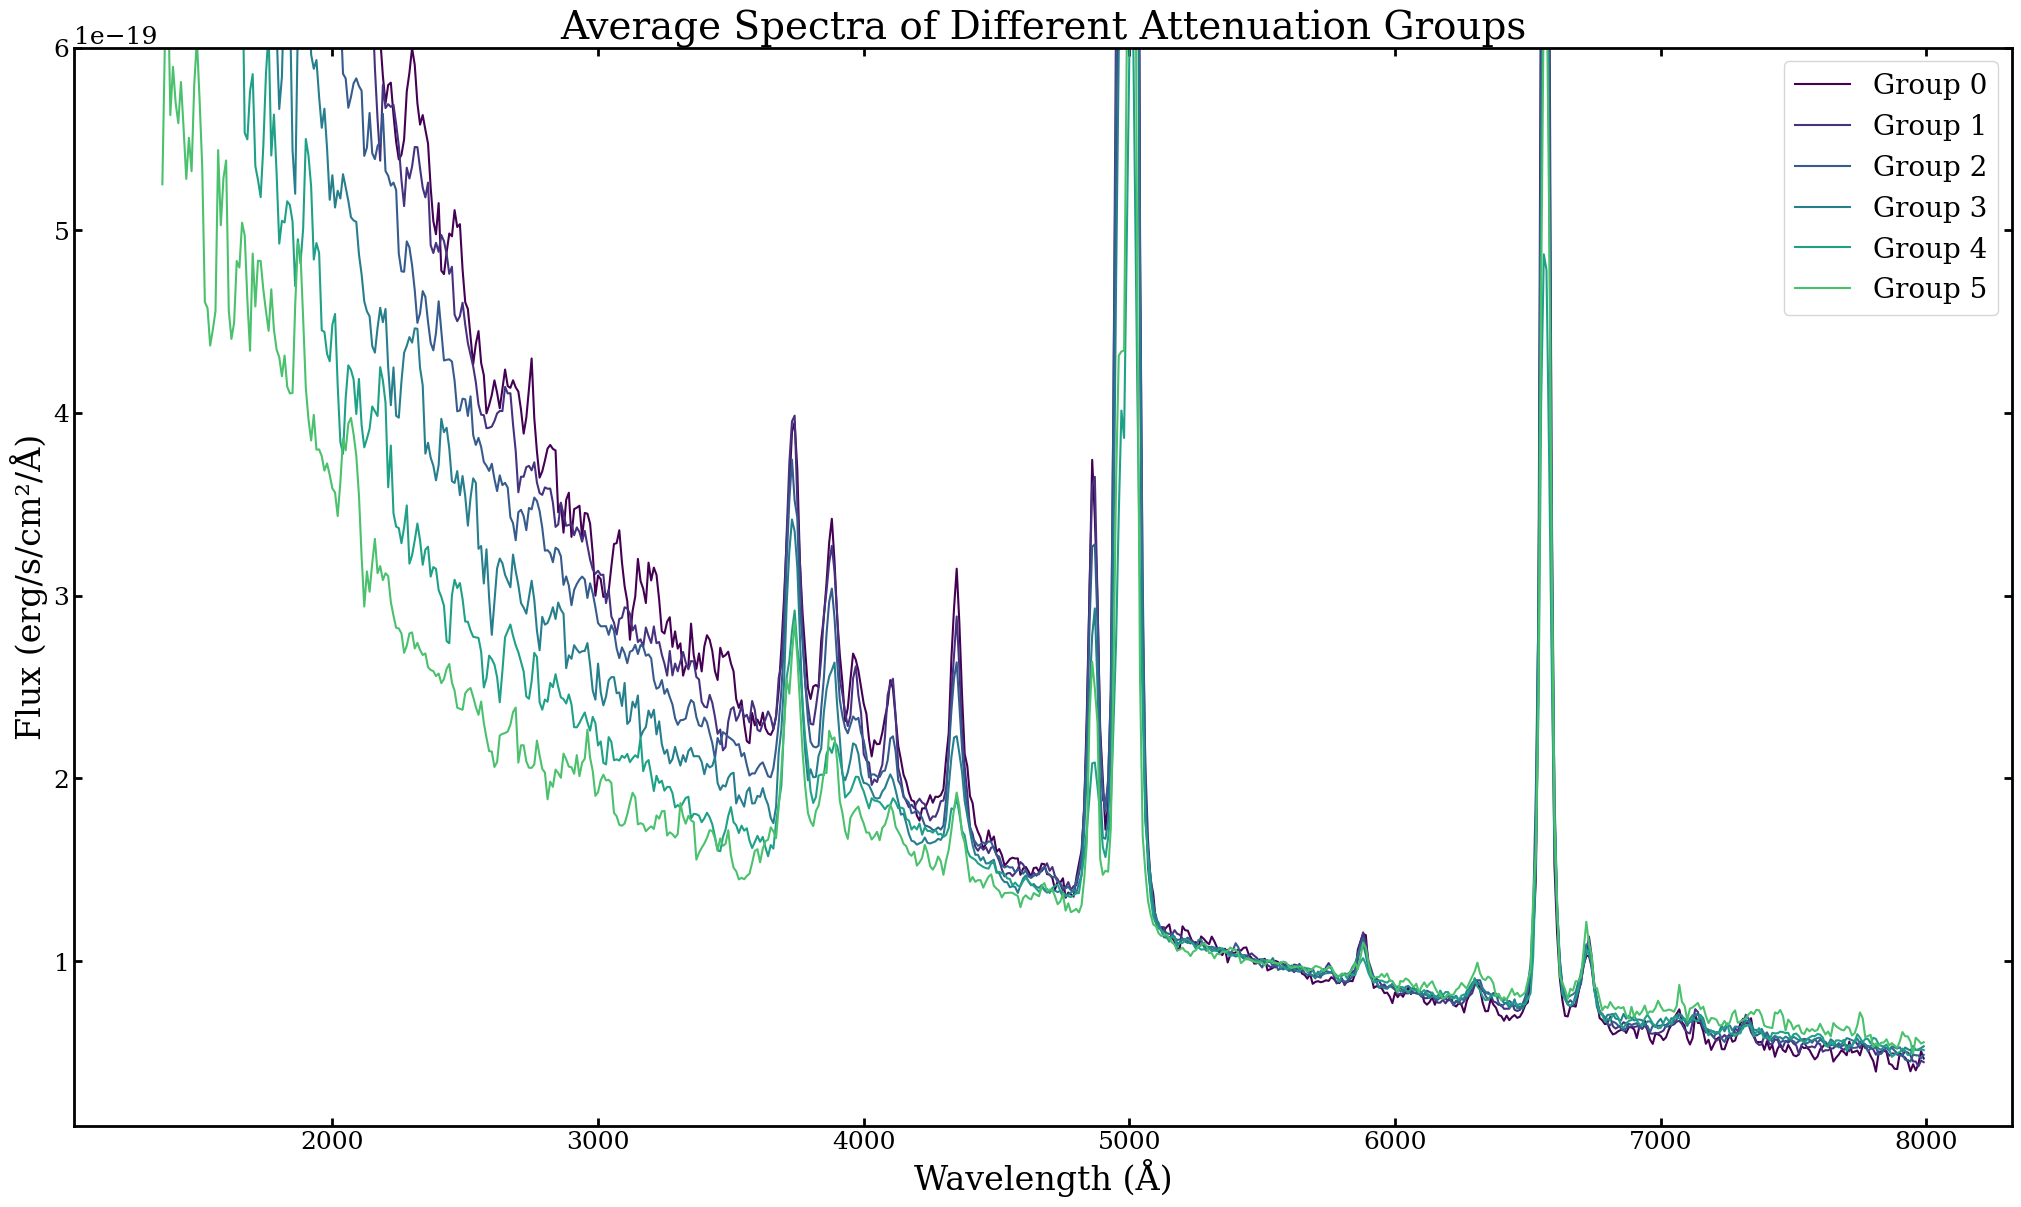

In [8]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,7))
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=24)
ax.legend(fontsize=20)
ax.set_title('Average Spectra of Different Attenuation Groups', fontsize=28)
ax.set_ylim(1e-20,6e-19)
plt.show()

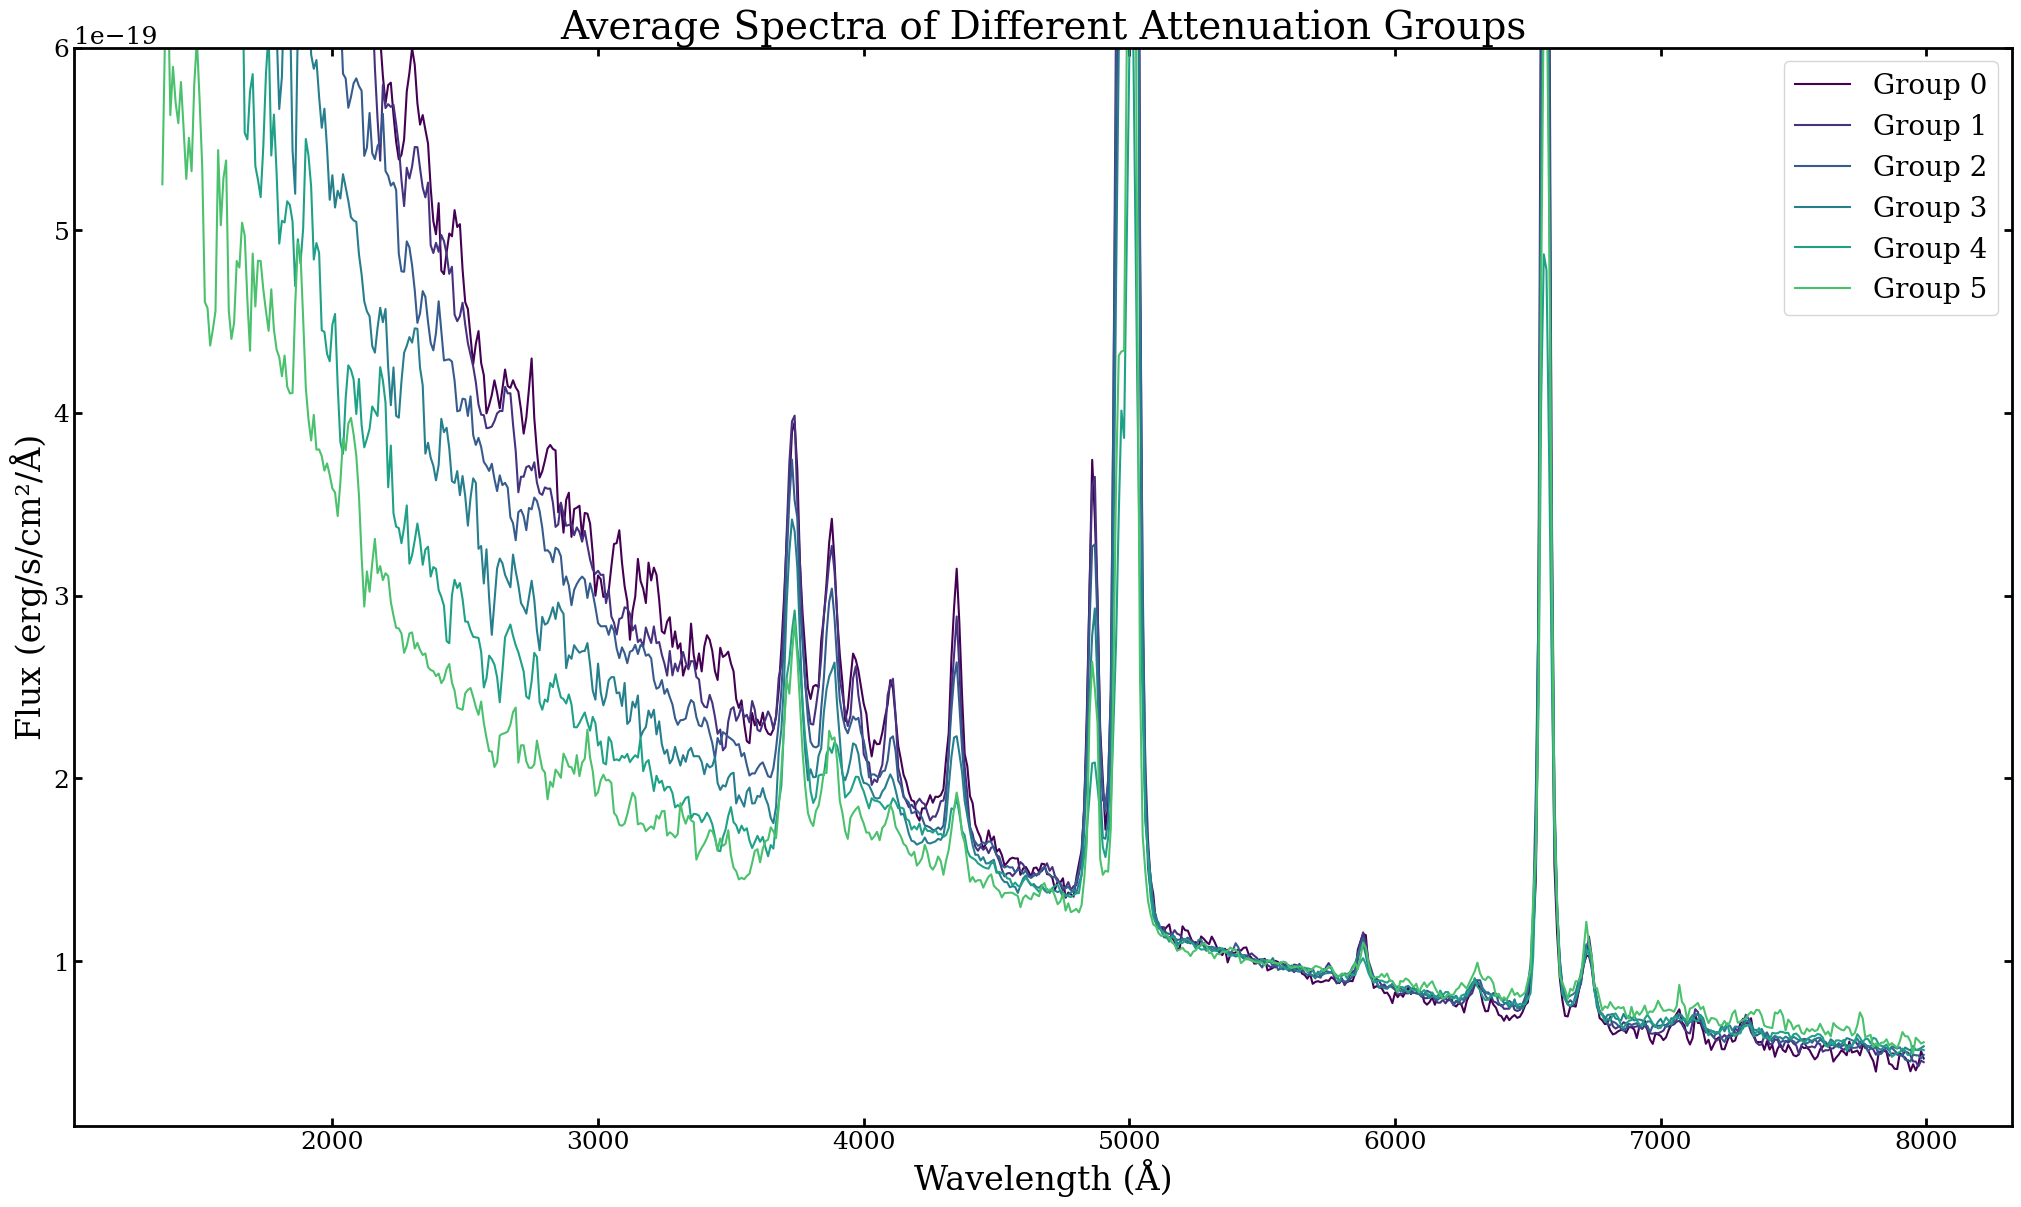

In [28]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,7))
for i in range(6):
    averager_to_use='group'+str(i)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, averager.average_flux, color=colors[i], label='Group '+str(i))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Flux (erg/s/cm²/Å)', fontsize=24)
ax.legend(fontsize=20)
ax.set_title('Average Spectra of Different Attenuation Groups', fontsize=28)
ax.set_ylim(1e-20,6e-19)
plt.show()

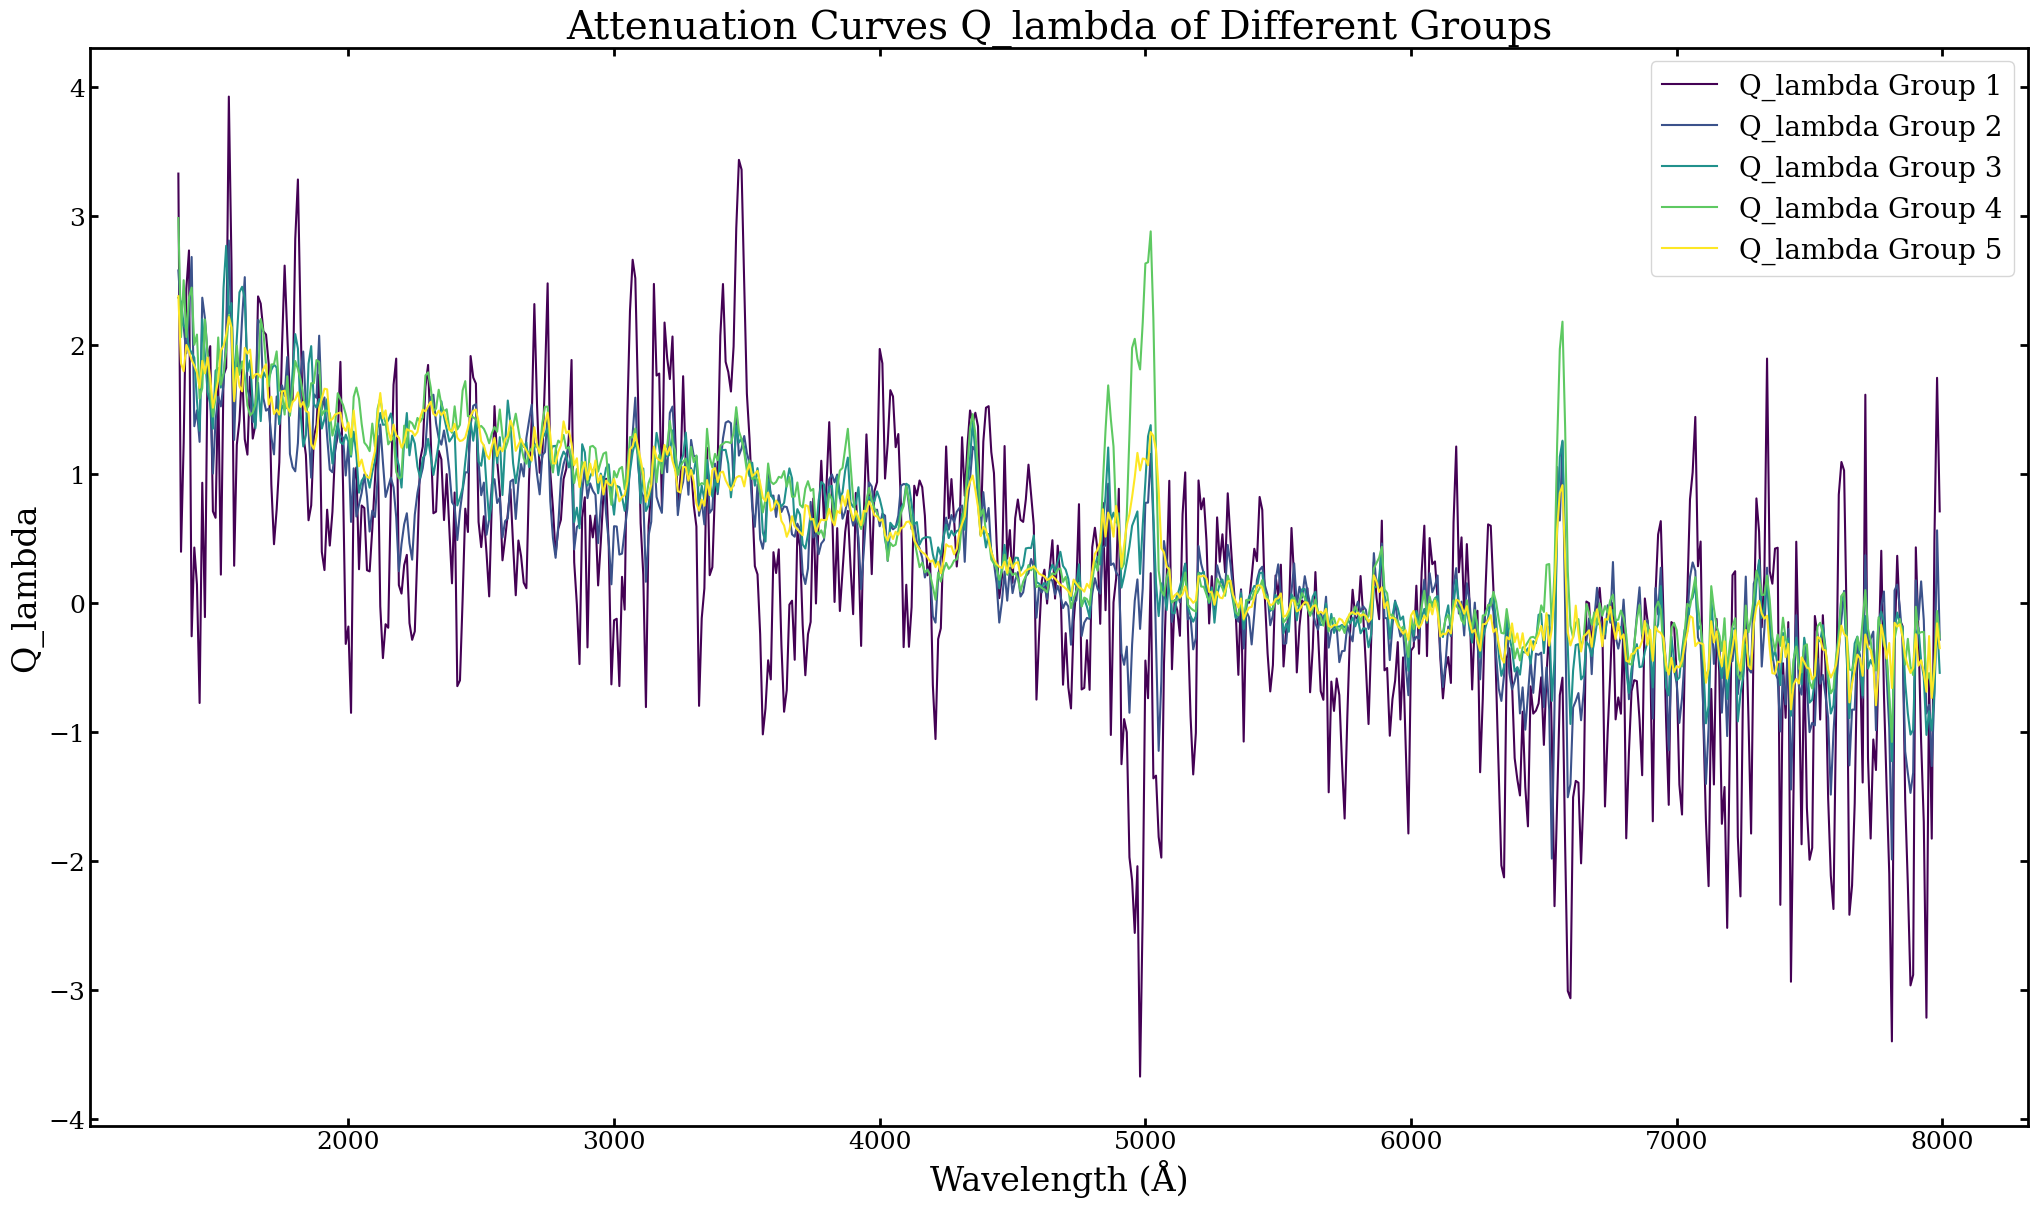

In [9]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,1,5))
for i in range(5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color=colors[i], label='Q_lambda Group '+str(i+1))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Q_lambda', fontsize=24)
ax.legend(fontsize=20)
ax.set_title('Attenuation Curves Q_lambda of Different Groups', fontsize=28)
plt.show()

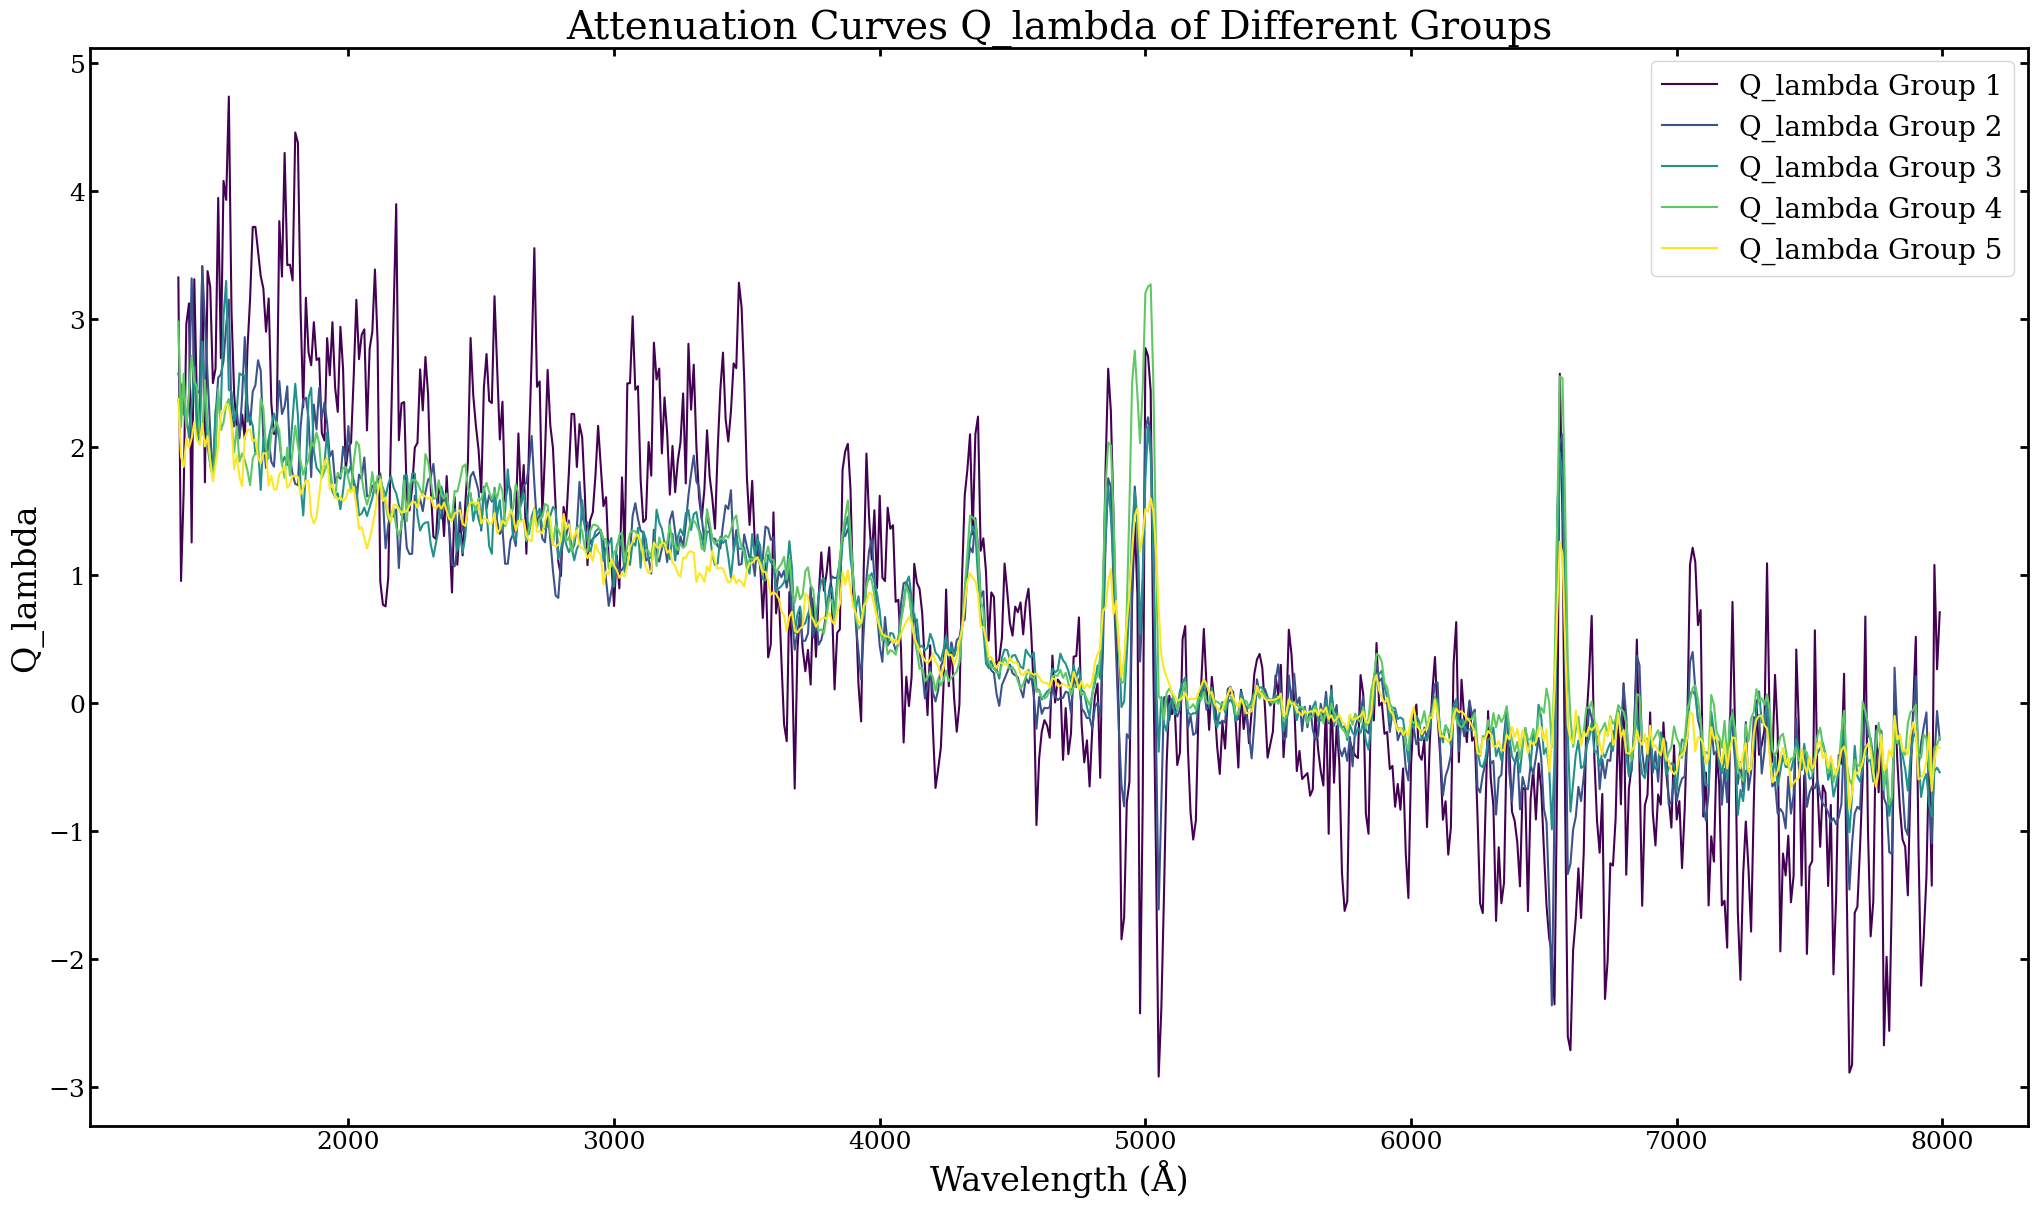

In [16]:
fig, ax=plt.subplots(figsize=(25,14))
colors=plt.cm.viridis(np.linspace(0,1,5))
for i in range(5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color=colors[i], label='Q_lambda Group '+str(i+1))
ax.set_xlabel('Wavelength (Å)', fontsize=24)
ax.set_ylabel('Q_lambda', fontsize=24)
ax.legend(fontsize=20)
ax.set_title('Attenuation Curves Q_lambda of Different Groups', fontsize=28)
plt.show()

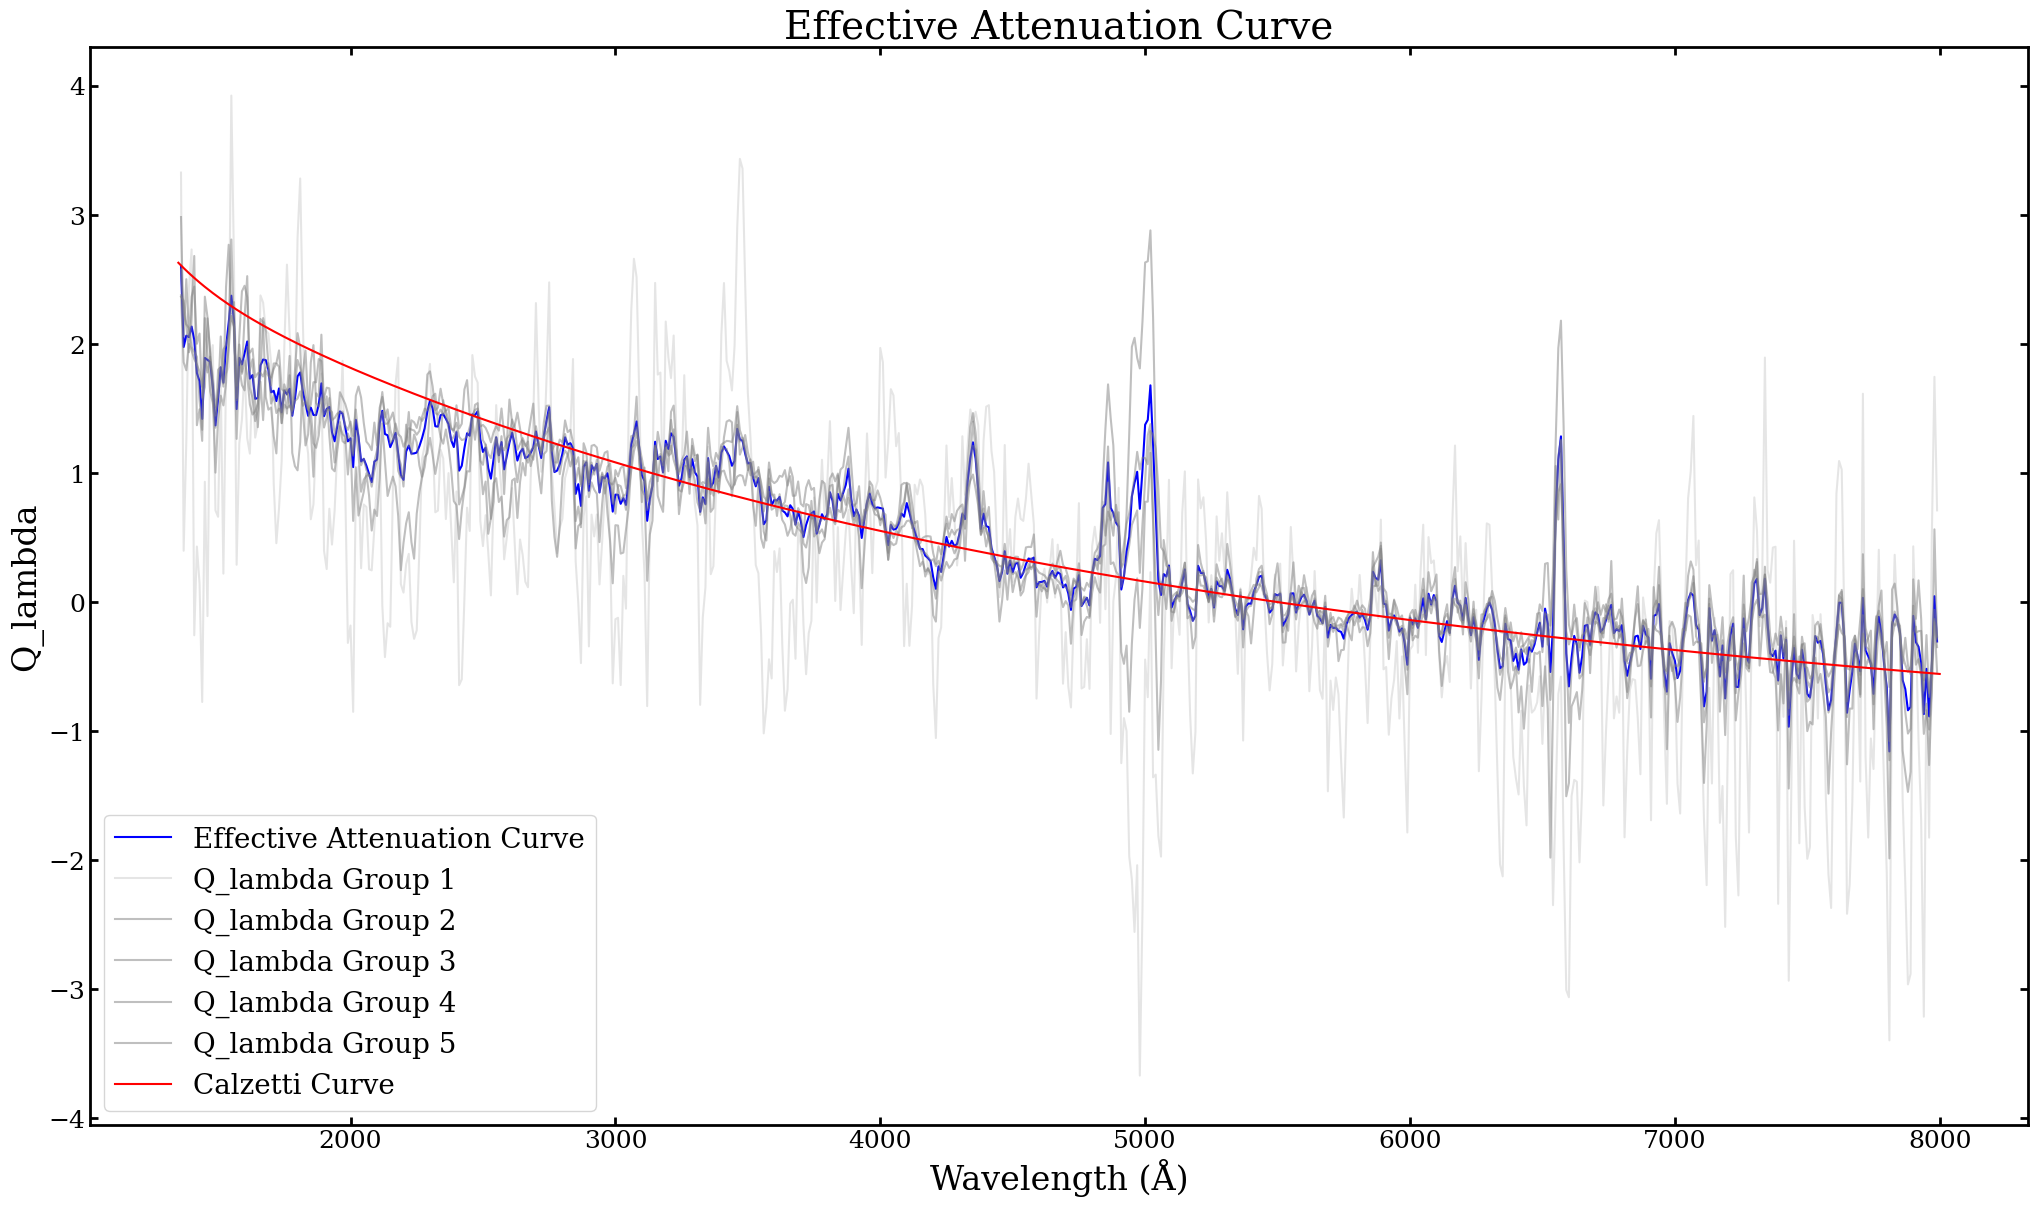

In [10]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

Q_lambda_array=np.array(Q_lambda_list)



effective_attenuation_curve=np.average(Q_lambda_array, axis=0, weights=[group_decrement_list[i]-group_decrement_list[0] for i in range(1,6)])
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
for i in range(0,5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=24)
plt.ylabel('Q_lambda', fontsize=24)
ax.set_title('Effective Attenuation Curve', fontsize=28)
plt.legend(fontsize=20)
plt.show()

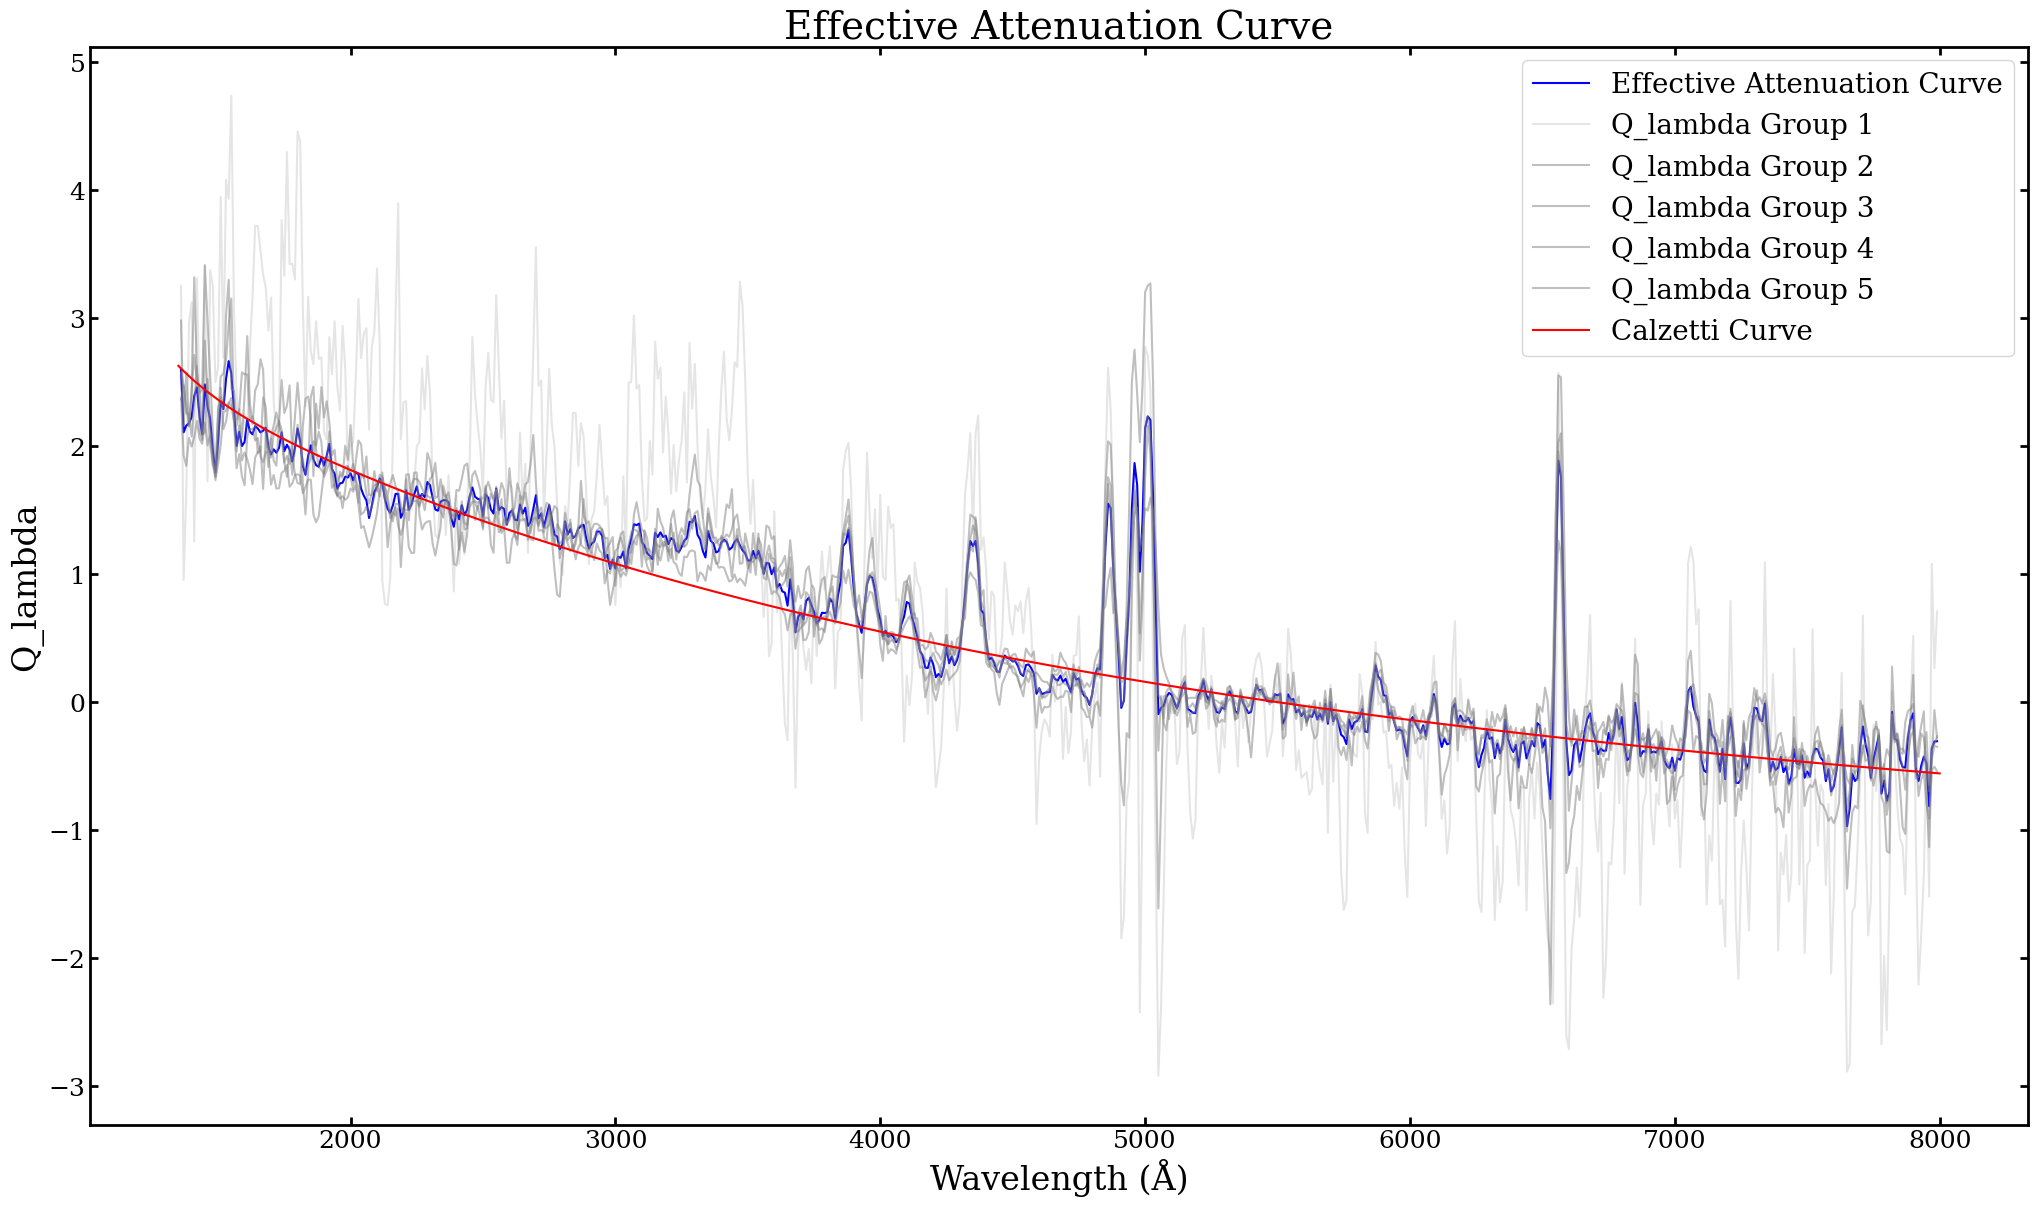

In [135]:
def Calzetti(input_lambda):
    x=1/input_lambda
    Q=-2.156+1.509*x-0.198*x**2+0.011*x**3
    return Q

Q_lambda_array=np.array(Q_lambda_list)


effective_attenuation_curve=np.average(Q_lambda_array, axis=0, weights=[group_decrement_list[i]-group_decrement_list[0] for i in range(1,6)])
fig, ax=plt.subplots(figsize=(25,14))
averager=group1_averager
ax.plot(averager.common_wavelength, effective_attenuation_curve, color='blue', label='Effective Attenuation Curve')
for i in range(0,5):
    Q_lambda=Q_lambda_list[i]
    averager_to_use='group'+str(i+1)+'_averager'
    averager=globals()[averager_to_use]
    ax.plot(averager.common_wavelength, Q_lambda, color='gray', alpha=0.5 if i!=0 else 0.2, label='Q_lambda Group '+str(i+1))

calzetti_curve=Calzetti((averager.common_wavelength*u.AA).to(u.micron).value)
ax.plot(averager.common_wavelength, calzetti_curve, color='red', label='Calzetti Curve')
plt.xlabel('Wavelength (Å)', fontsize=24)
plt.ylabel('Q_lambda', fontsize=24)
ax.set_title('Effective Attenuation Curve', fontsize=28)
plt.legend(fontsize=20)
plt.show()

---
## Here we will fit each Q_lambda with the same order polynomial as Calzetti et al. (2000)
---

In [19]:
def polynomial_for_Q_fitting(input_lambda, a0, a1, a2, a3):
    x=1/input_lambda
    Q=a0 + a1*x + a2*x**2 + a3*x**3
    return Q

## First we will run a smoothing function to get a smooth curve for fitting

In [20]:
from scipy.signal import savgol_filter

Fitted coefficients for Group 1: [-3.75484874  2.95696504 -0.62651022  0.04471716]
Function: Q = -3.7548 + 2.9570*(1/lambda) + -0.6265*(1/lambda)^2 + 0.0447*(1/lambda)^3
Fitted coefficients for Group 2: [-2.738931    2.19117413 -0.44554119  0.03292916]
Function: Q = -2.7389 + 2.1912*(1/lambda) + -0.4455*(1/lambda)^2 + 0.0329*(1/lambda)^3
Fitted coefficients for Group 3: [-2.71867121  2.14936577 -0.40310358  0.02765574]
Function: Q = -2.7187 + 2.1494*(1/lambda) + -0.4031*(1/lambda)^2 + 0.0277*(1/lambda)^3
Fitted coefficients for Group 4: [-2.39525095  1.86437039 -0.31437875  0.01990593]
Function: Q = -2.3953 + 1.8644*(1/lambda) + -0.3144*(1/lambda)^2 + 0.0199*(1/lambda)^3
Fitted coefficients for Group 5: [-2.35448503  1.77830078 -0.2891082   0.01741631]
Function: Q = -2.3545 + 1.7783*(1/lambda) + -0.2891*(1/lambda)^2 + 0.0174*(1/lambda)^3


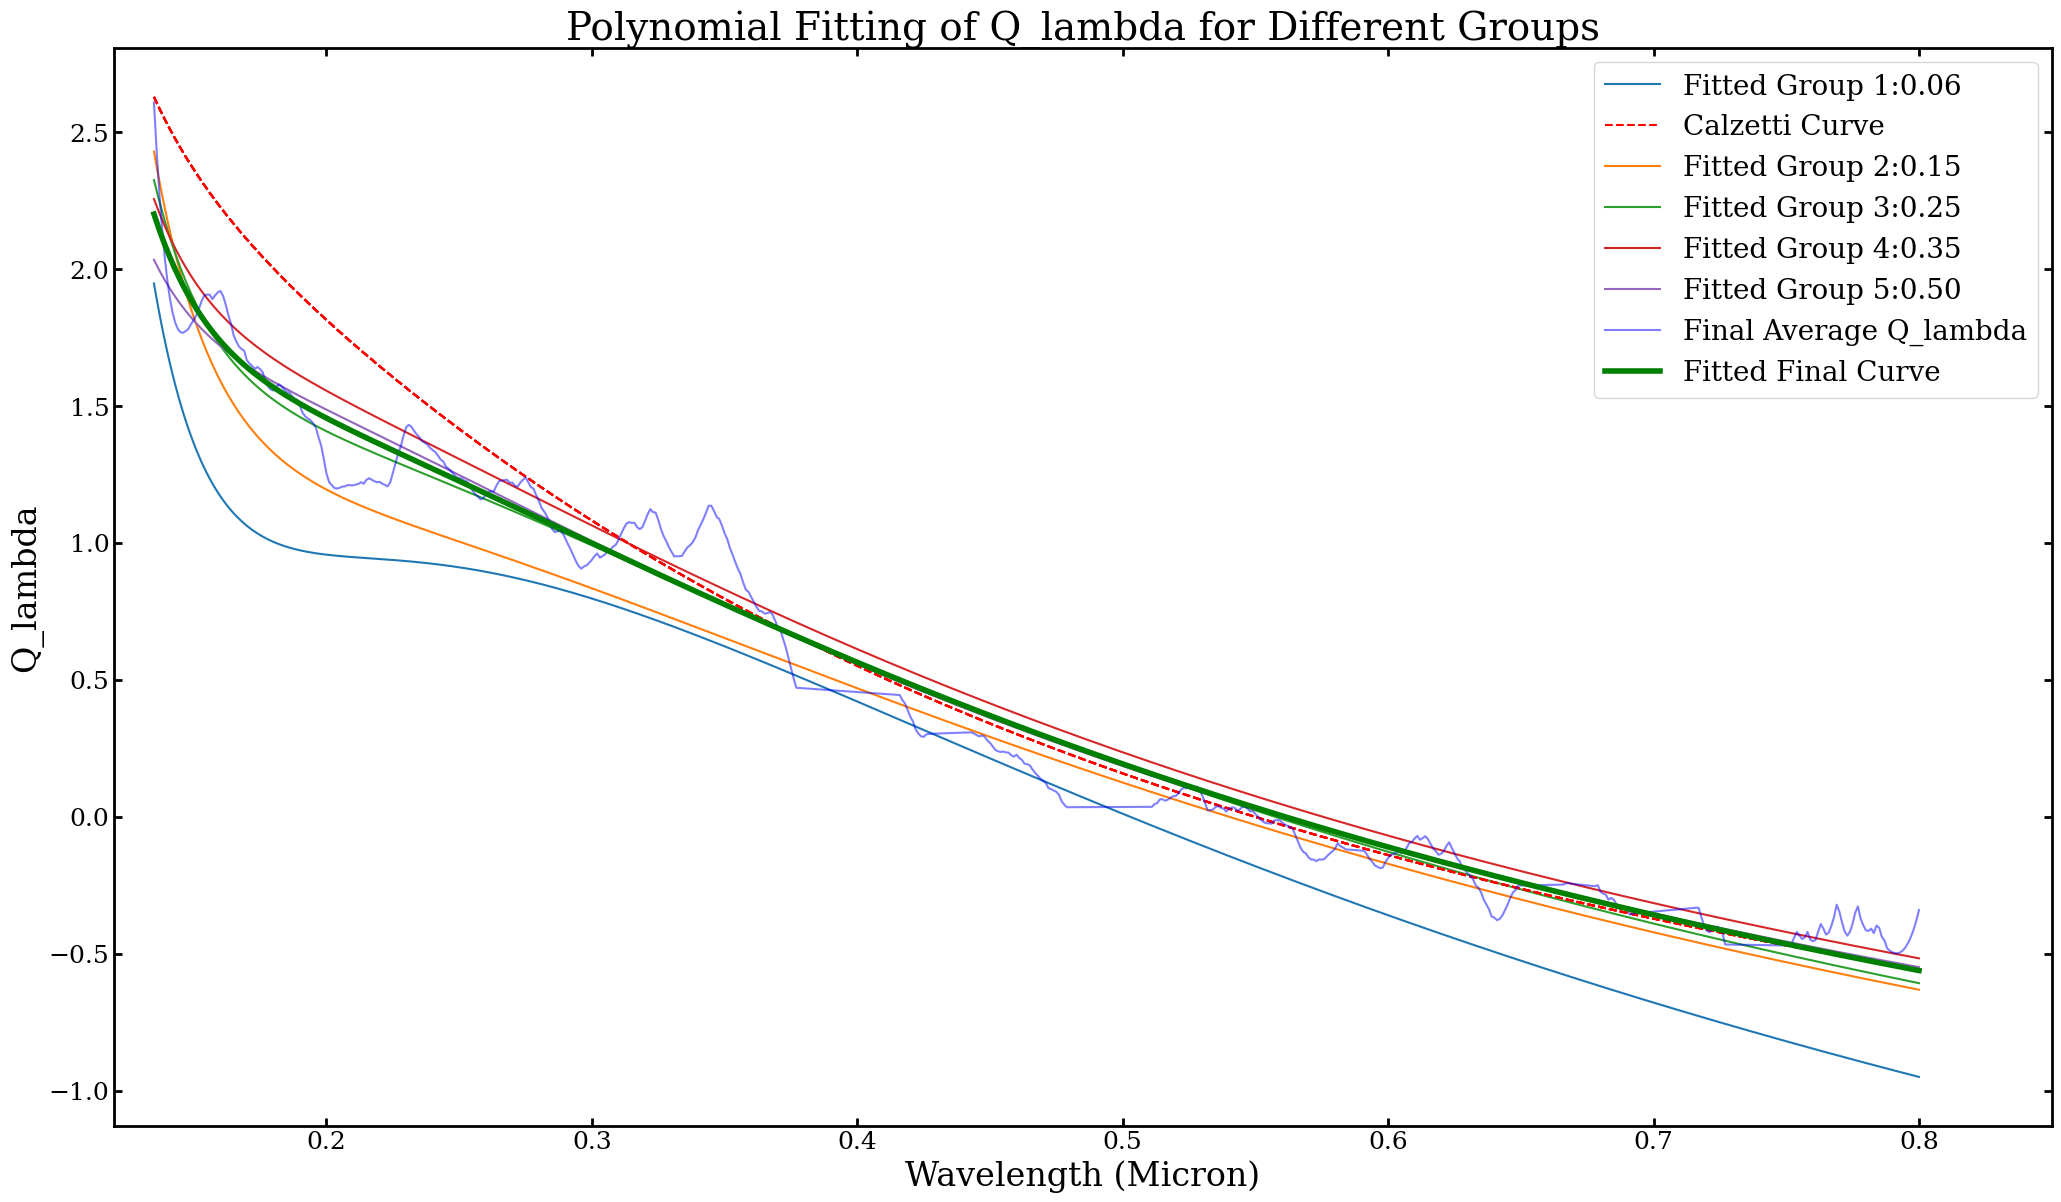

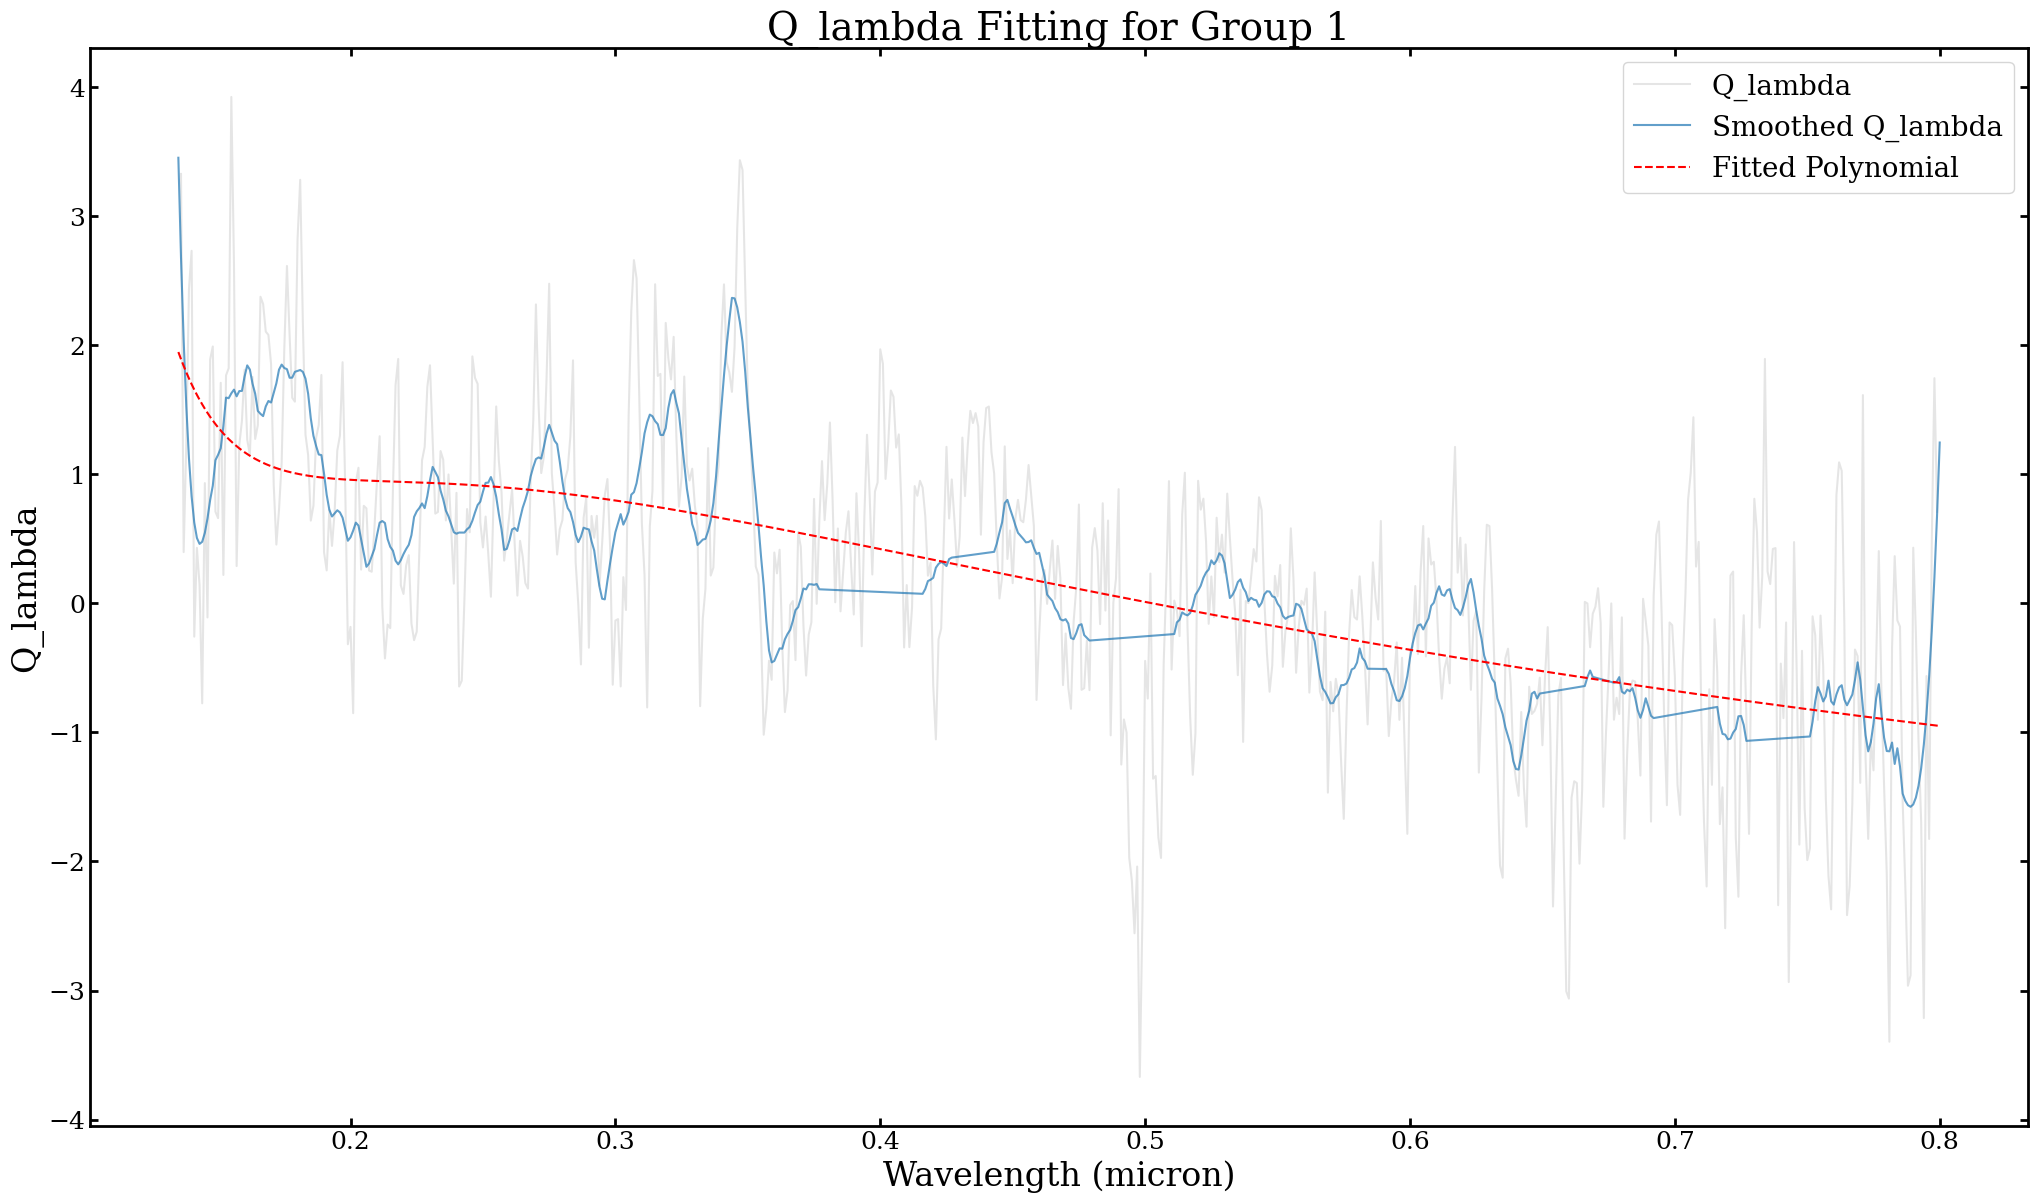

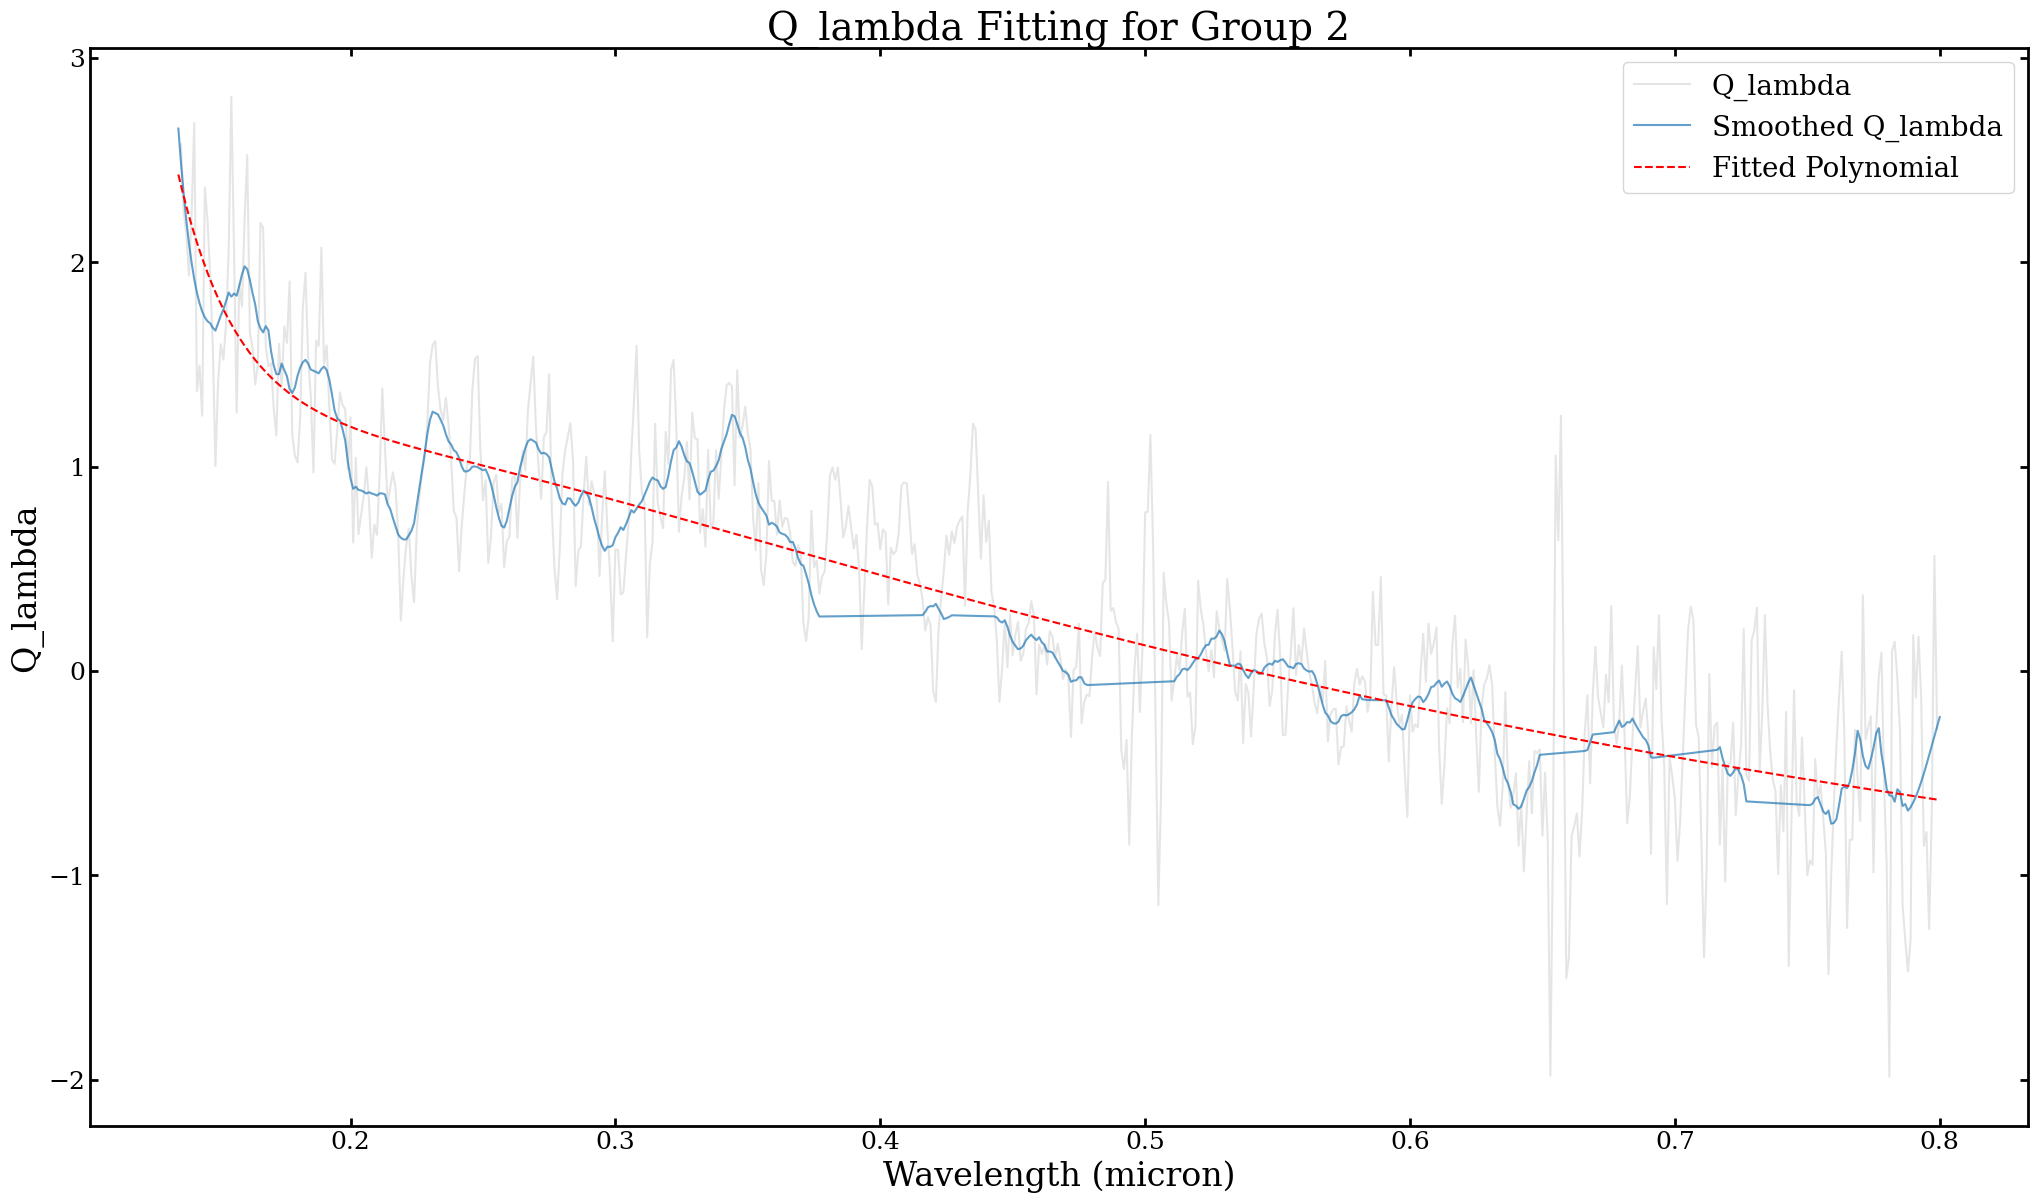

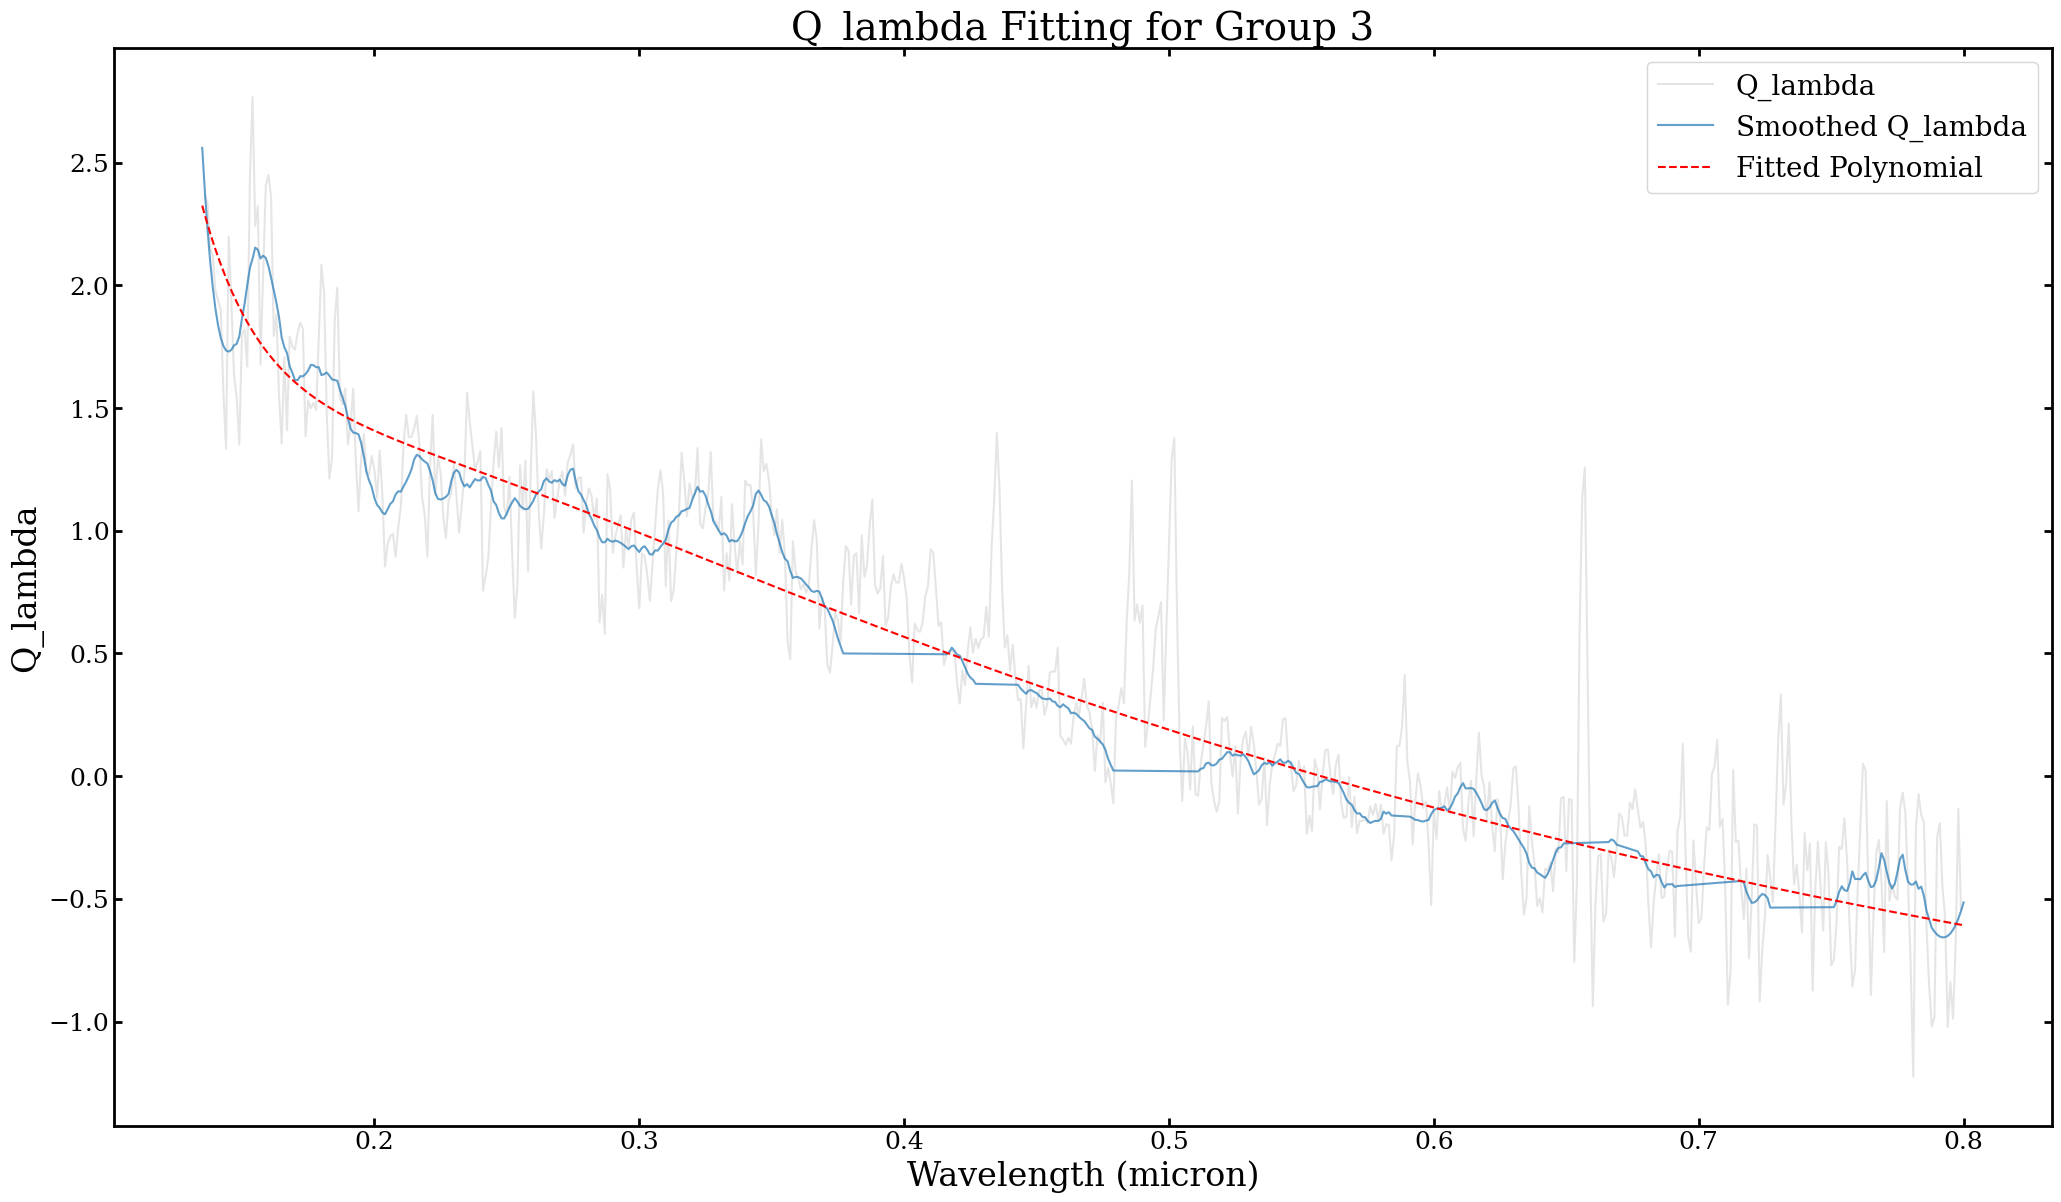

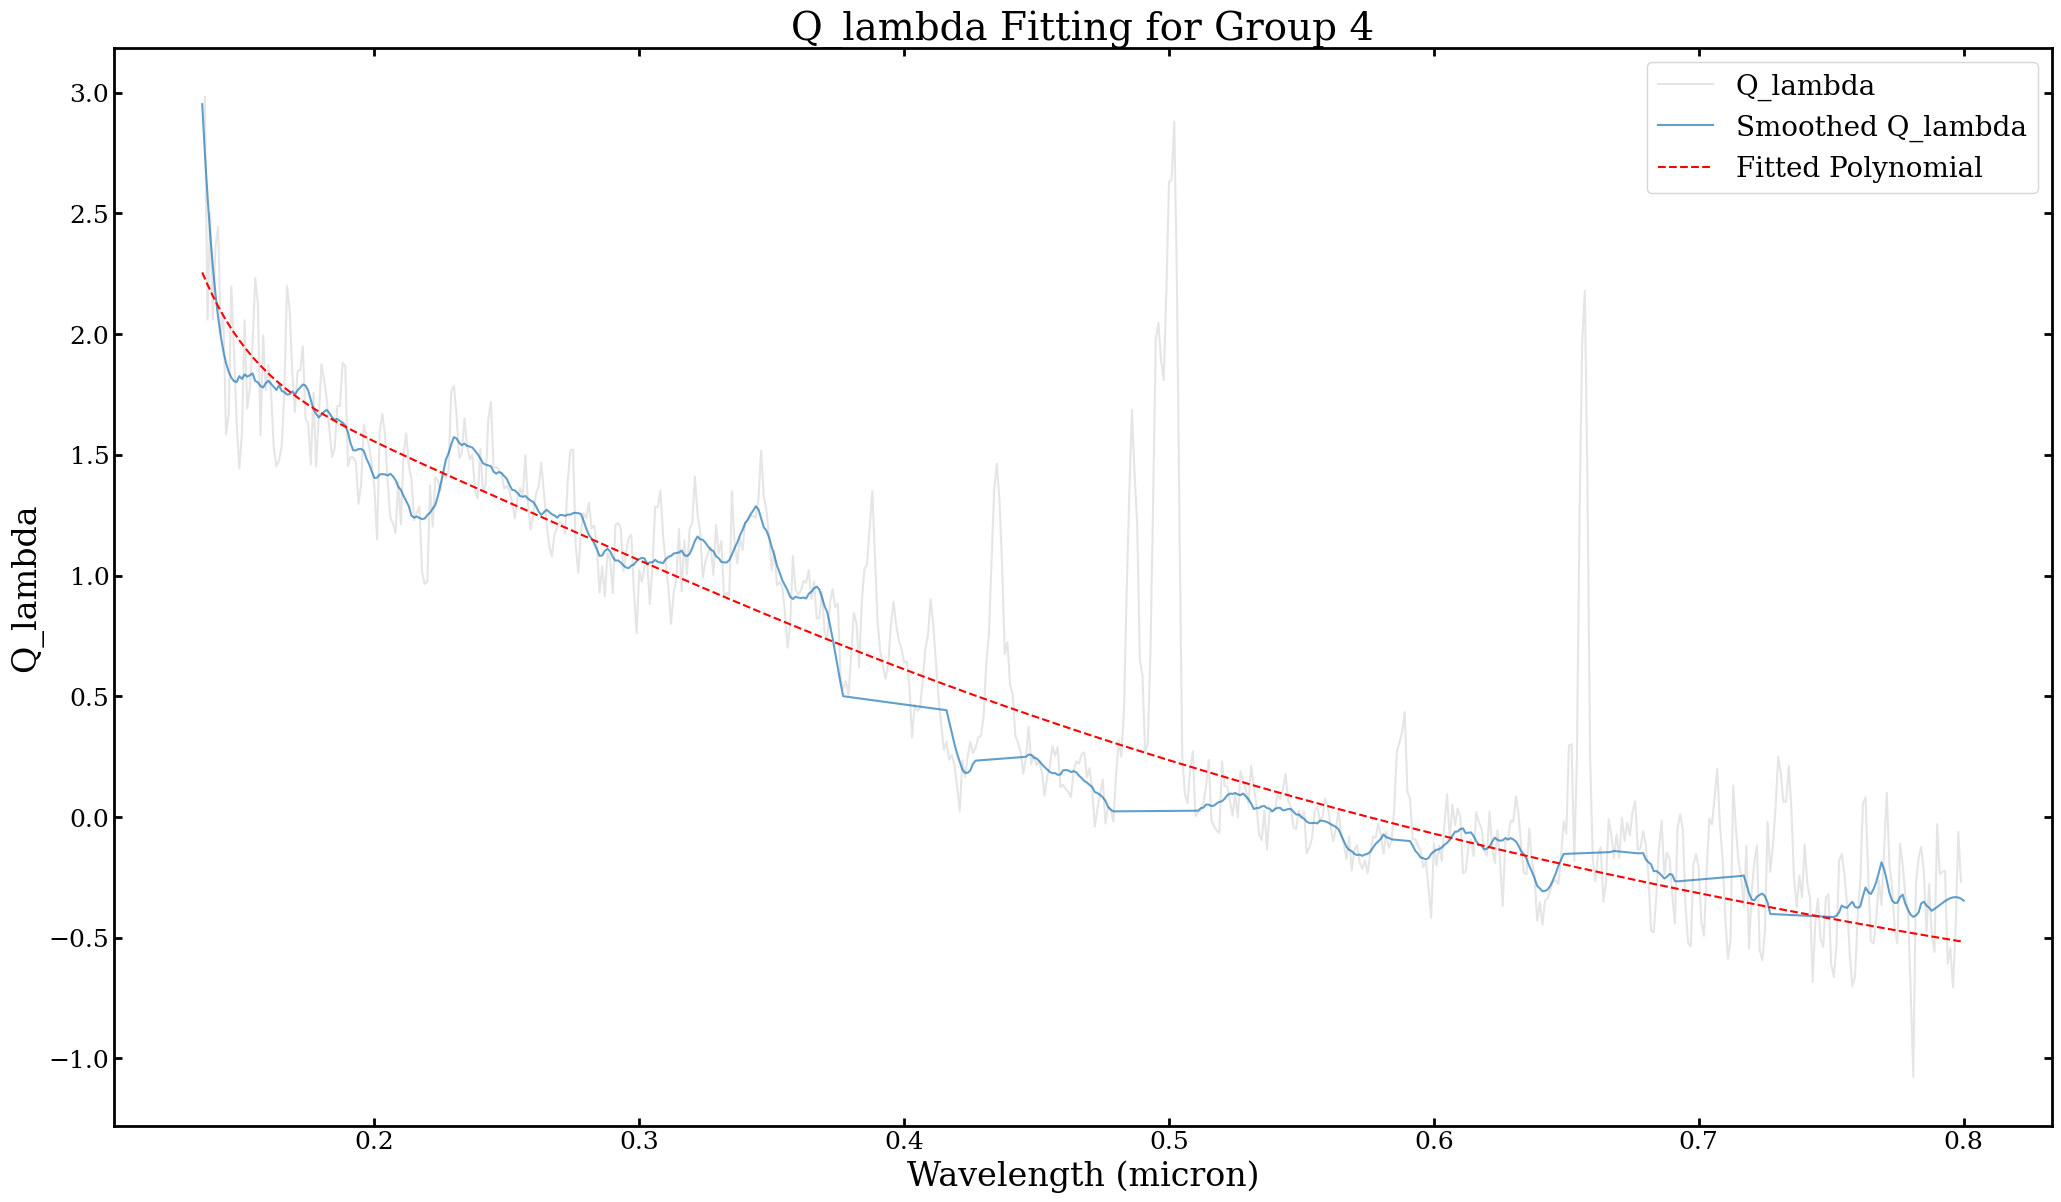

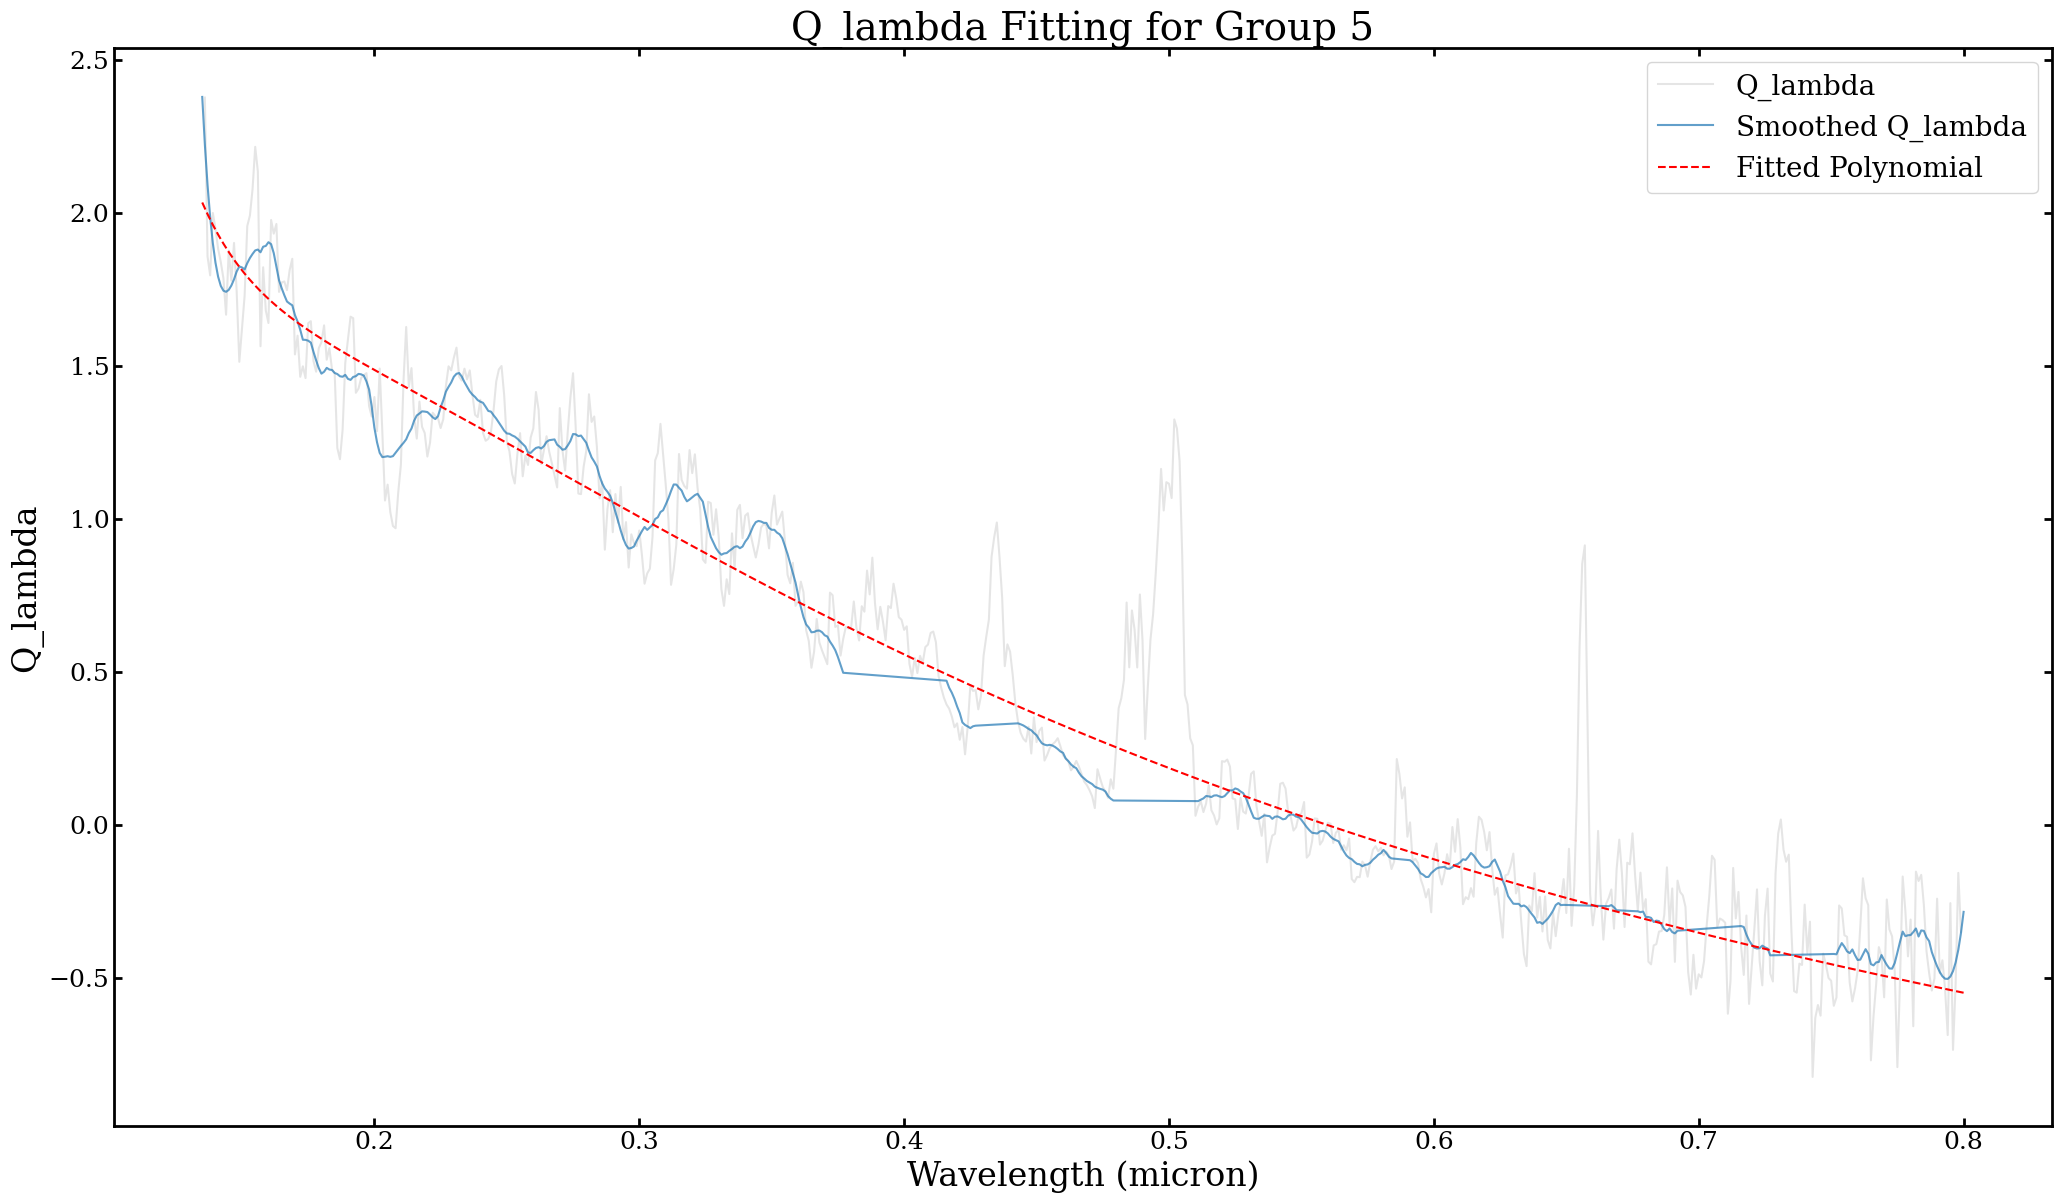

In [31]:
mask_regions = [
    (3775,4150),
    (4280, 4425),  # Ca II H+K
    (4800, 5100),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (6925,7150),
    (7275,7500),
]

window_len = 25
poly_order = 3

fig, ax = plt.subplots(figsize=(25,14))
Smoothed_Q_array=[]
Poly_Fit=[]
popts, pcovs = [], []

for i in range(Q_lambda_array.shape[0]):
    wavelengths=averager.common_wavelength/10000
    Q_lambda=Q_lambda_array[i]


    series_curve = pd.Series(Q_lambda, index=wavelengths)
    curve_clean = series_curve.replace([np.inf, -np.inf], np.nan).interpolate(method='linear', limit_direction='both')
    curve_clean = curve_clean.to_numpy()

    mask=np.ones_like(wavelengths, dtype=bool)
    for (low, high) in mask_regions:
        low, high = float(low)/10000, float(high)/10000
        mask &= ~((wavelengths >= low) & (wavelengths <= high))

    valid_data=np.isfinite(curve_clean) & np.isfinite(wavelengths) & mask

    smoothed_curve = savgol_filter(curve_clean[valid_data], window_length=window_len, polyorder=poly_order)

    subfig, subax = plt.subplots(figsize=(25,14))
    subax.plot(wavelengths,Q_lambda, color='gray', alpha=0.2,label='Q_lambda')
    subax.plot(wavelengths[valid_data], smoothed_curve, label='Smoothed Q_lambda',alpha=0.7)

    popt, pcov = scipy.optimize.curve_fit(polynomial_for_Q_fitting, wavelengths[valid_data], smoothed_curve)
    popts.append(popt)
    pcovs.append(pcov)

    fitted_curve = polynomial_for_Q_fitting(wavelengths, *popt)
    subax.plot(wavelengths, fitted_curve, color='red', linestyle='--', label='Fitted Polynomial')
    subax.set_xlabel('Wavelength (micron)', fontsize=24)
    subax.set_ylabel('Q_lambda', fontsize=24)
    subax.set_title('Q_lambda Fitting for Group '+str(i+1), fontsize=28)
    subax.legend(fontsize=20)
    print('Fitted coefficients for Group '+str(i+1)+':', popt)
    print('Function: Q = {:.4f} + {:.4f}*(1/lambda) + {:.4f}*(1/lambda)^2 + {:.4f}*(1/lambda)^3'.format(*popt))

    ax.plot(wavelengths, fitted_curve, label='Fitted Group '+str(i+1)+":"+f"{group_decrement_list[i+1]:.2f}")
    ax.plot(wavelengths, Calzetti(wavelengths), color='red', linestyle='--', label='Calzetti Curve' if i==0 else "")


    Smoothed_Q_array.append(smoothed_curve)
    Smoothed_Wavelengths=wavelengths


ax.set_xlabel('Wavelength (Micron)', fontsize=24)
ax.set_ylabel('Q_lambda', fontsize=24)
ax.set_title('Polynomial Fitting of Q_lambda for Different Groups', fontsize=28)

Smoothed_Q_array=np.array(Smoothed_Q_array)
Final_Q_array=np.average(Smoothed_Q_array[1:], weights=[group_decrement_list[i]-group_decrement_list[0] for i in range(2,6)], axis=0)


ax.plot(Smoothed_Wavelengths[valid_data], Final_Q_array, color='blue', linestyle='-', label='Final Average Q_lambda',alpha=0.5)

popt, pcov = scipy.optimize.curve_fit(polynomial_for_Q_fitting, Smoothed_Wavelengths[valid_data], Final_Q_array)
fitted_final_curve = polynomial_for_Q_fitting(Smoothed_Wavelengths, *popt)
ax.plot(Smoothed_Wavelengths, fitted_final_curve, color='green', label='Fitted Final Curve',linewidth=4)
ax.set_xlim(0.12,0.85)
ax.legend(fontsize=20)
plt.show()


Fitted coefficients for Group 1: [-3.84459871  2.51563947 -0.29942073  0.01118241]
Function: Q = -3.8446 + 2.5156*(1/lambda) + -0.2994*(1/lambda)^2 + 0.0112*(1/lambda)^3
Fitted coefficients for Group 2: [-2.89453954  2.1353284  -0.34900091  0.02266433]
Function: Q = -2.8945 + 2.1353*(1/lambda) + -0.3490*(1/lambda)^2 + 0.0227*(1/lambda)^3
Fitted coefficients for Group 3: [-2.81028224  2.11424128 -0.344778    0.02144762]
Function: Q = -2.8103 + 2.1142*(1/lambda) + -0.3448*(1/lambda)^2 + 0.0214*(1/lambda)^3
Fitted coefficients for Group 4: [-2.23809381  1.59182096 -0.19338763  0.00794064]
Function: Q = -2.2381 + 1.5918*(1/lambda) + -0.1934*(1/lambda)^2 + 0.0079*(1/lambda)^3
Fitted coefficients for Group 5: [-2.34443654  1.70000962 -0.24101136  0.01255225]
Function: Q = -2.3444 + 1.7000*(1/lambda) + -0.2410*(1/lambda)^2 + 0.0126*(1/lambda)^3


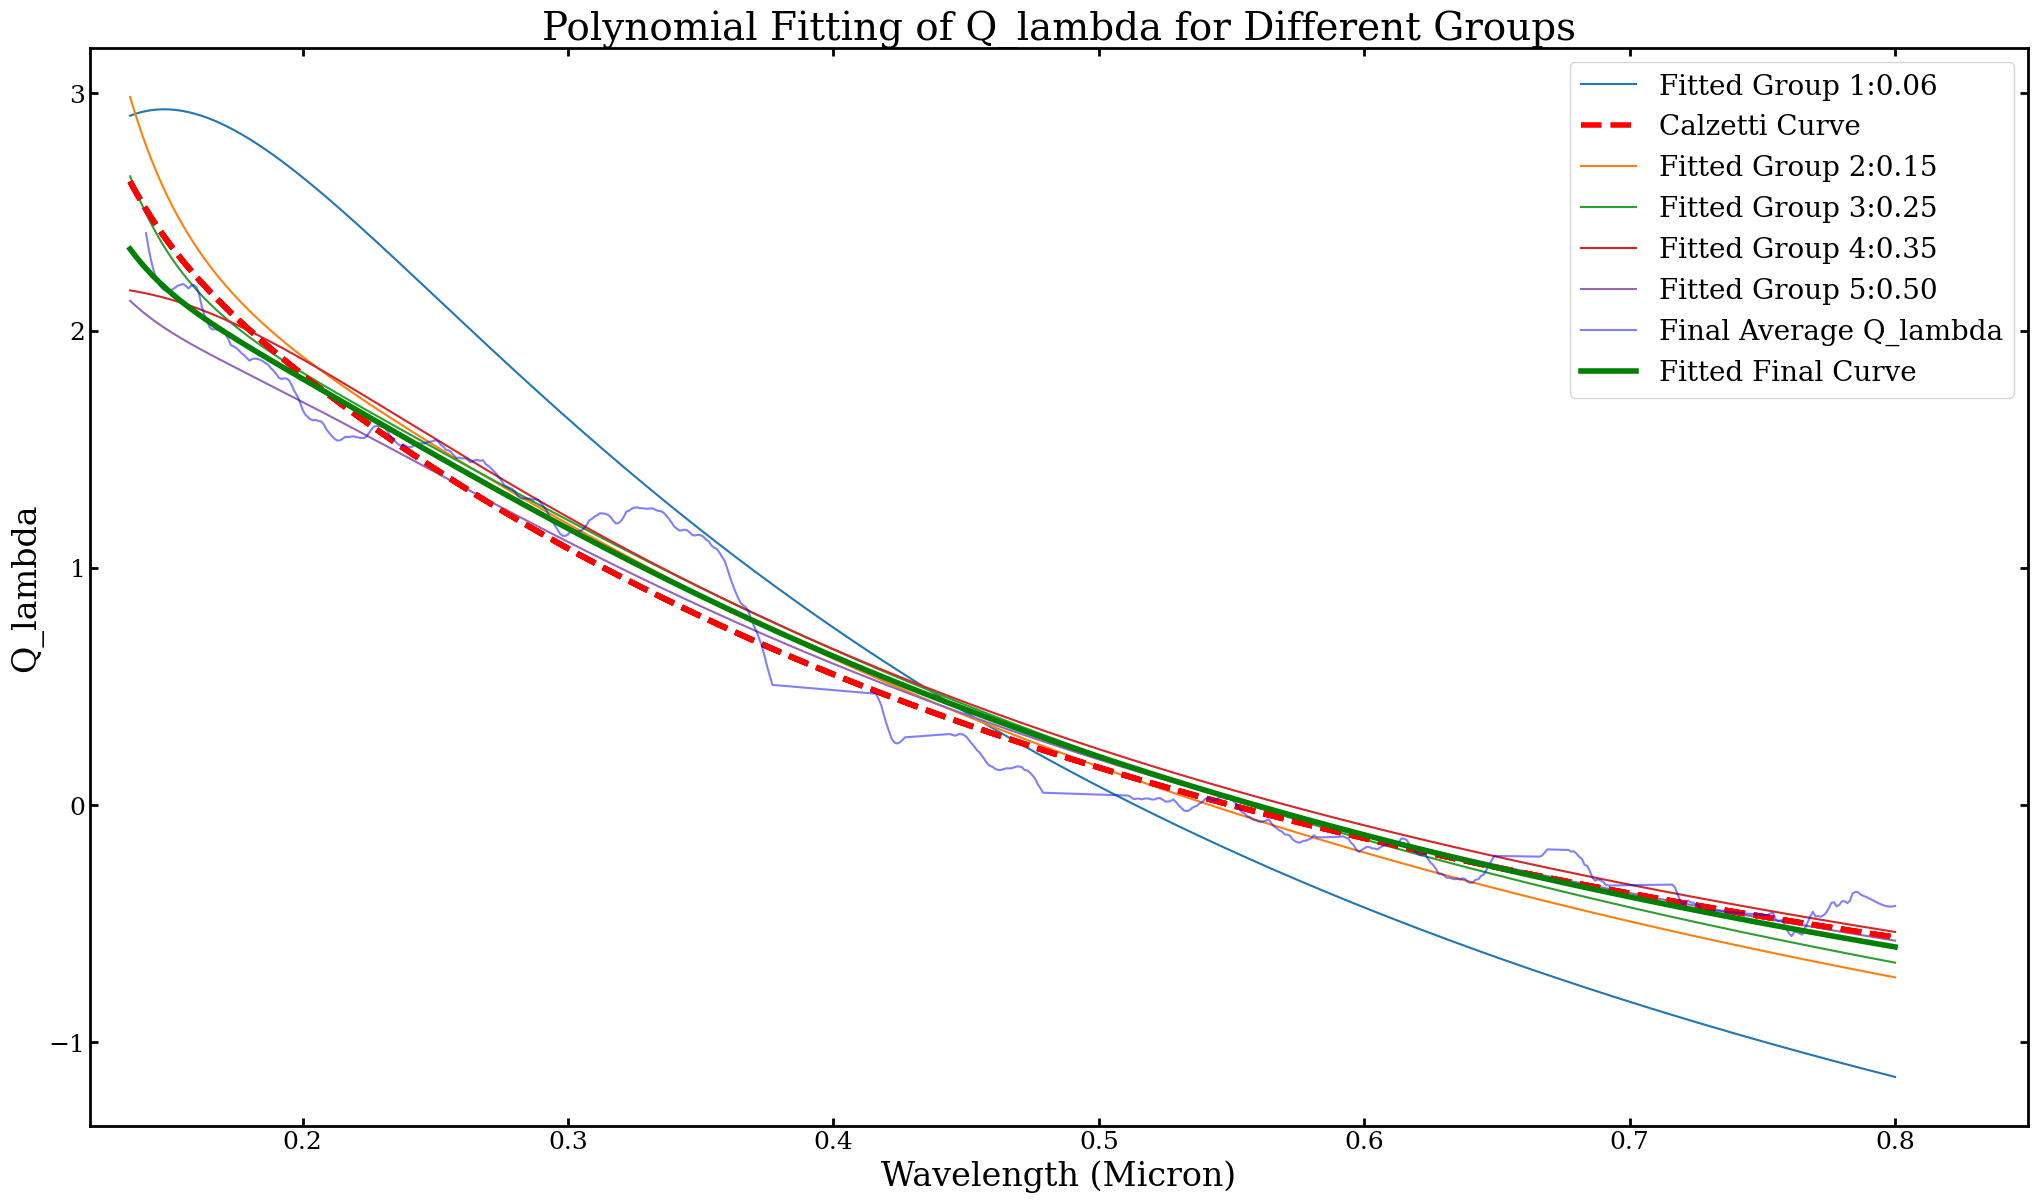

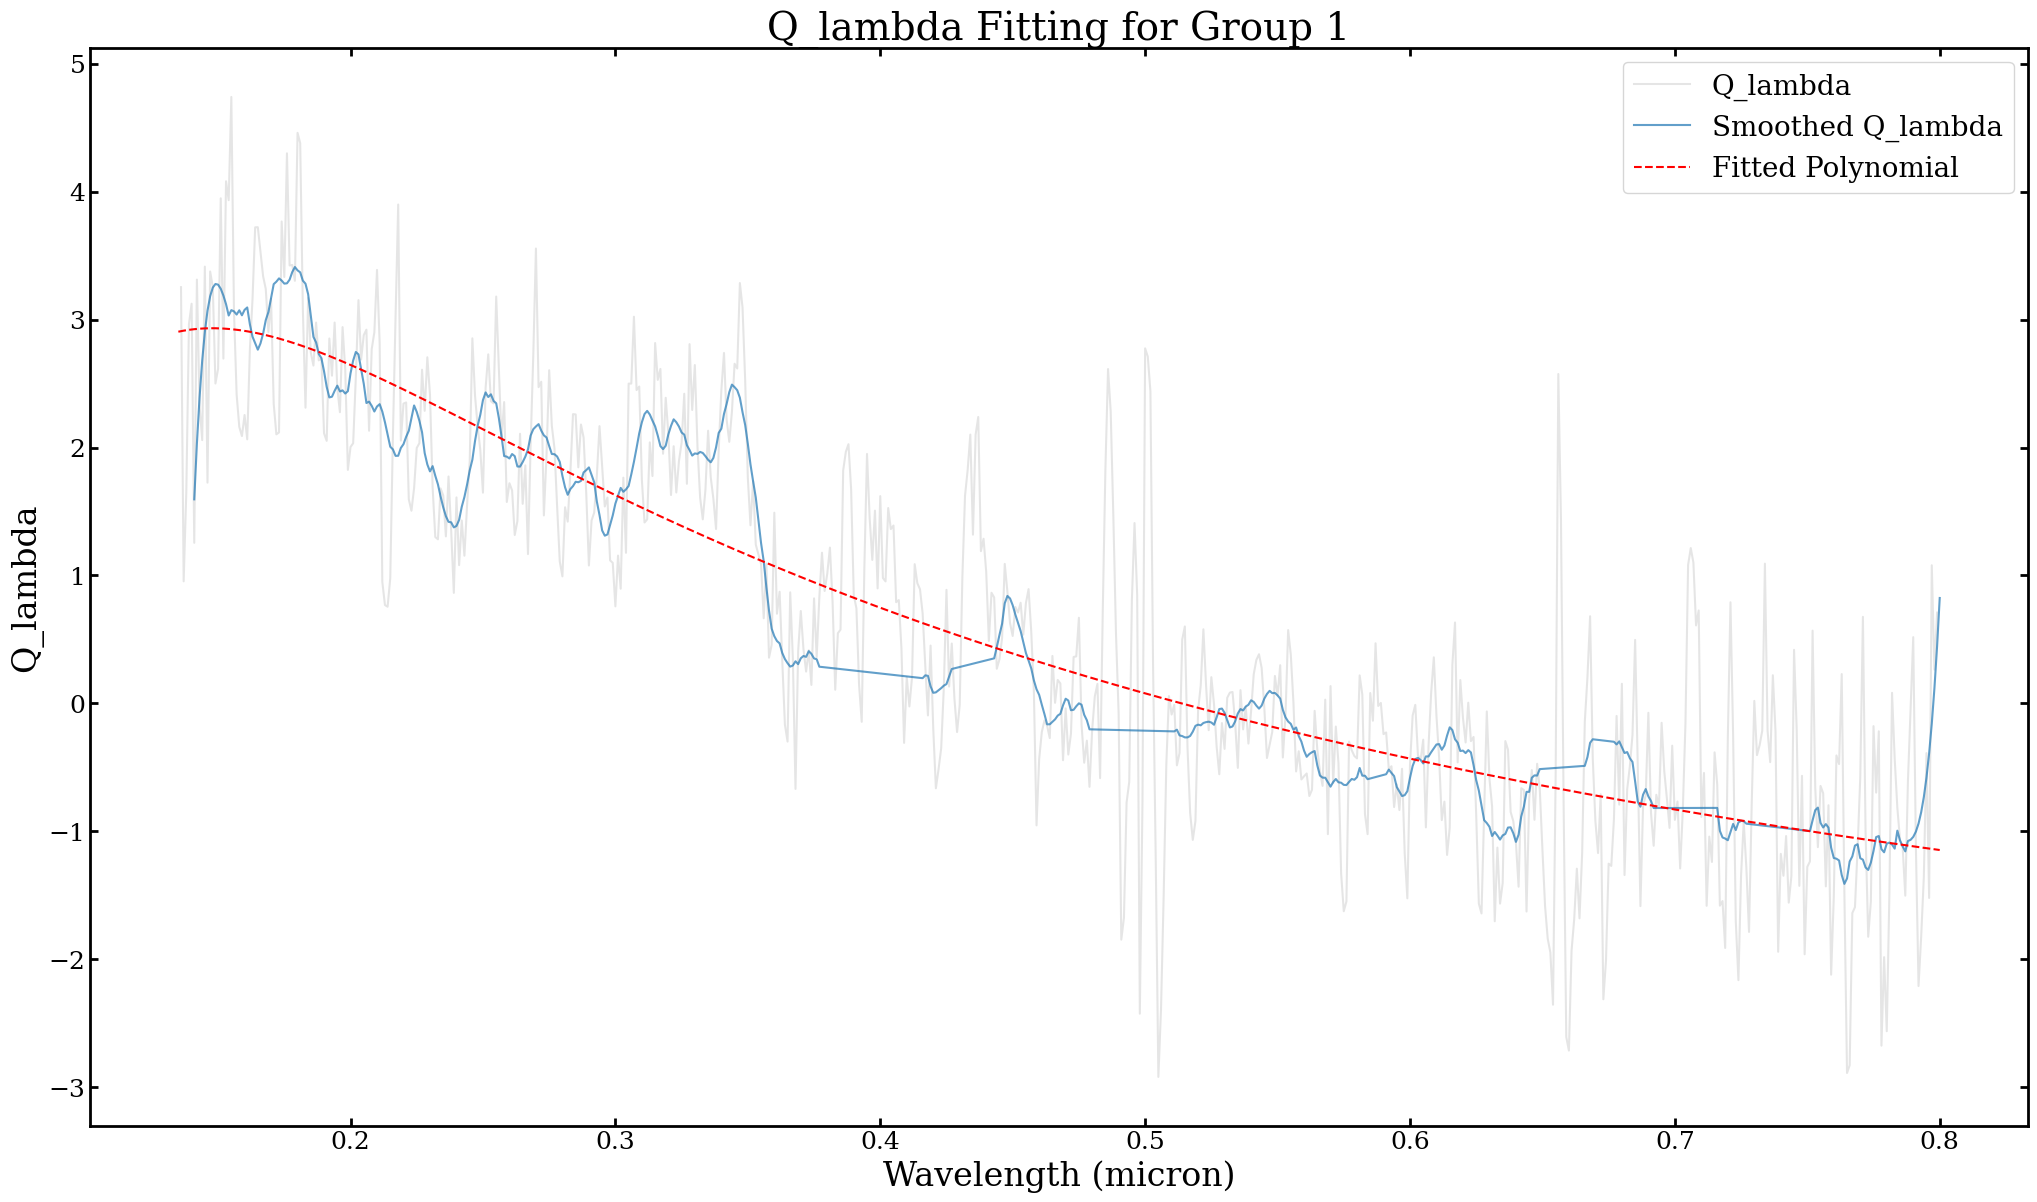

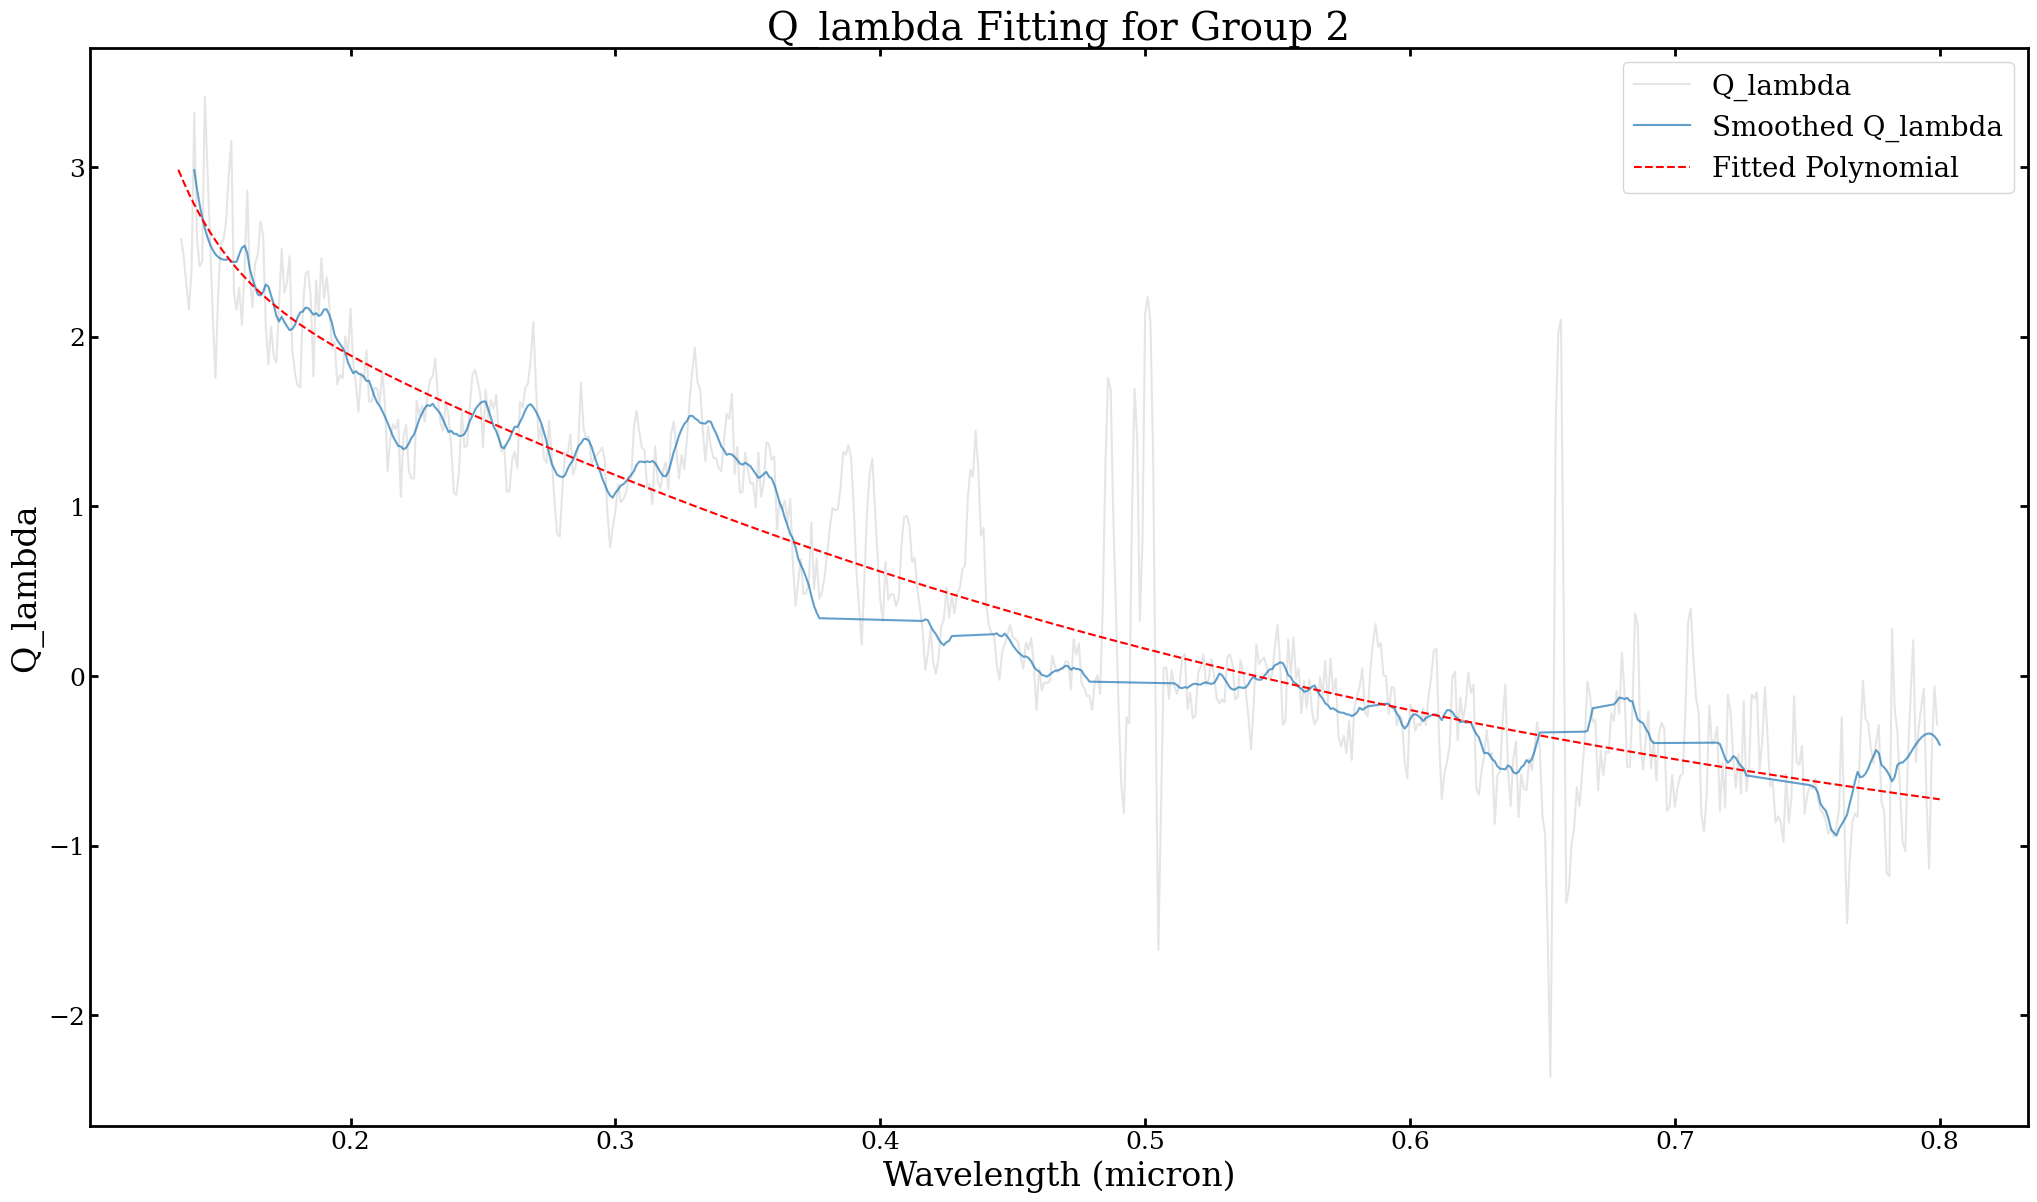

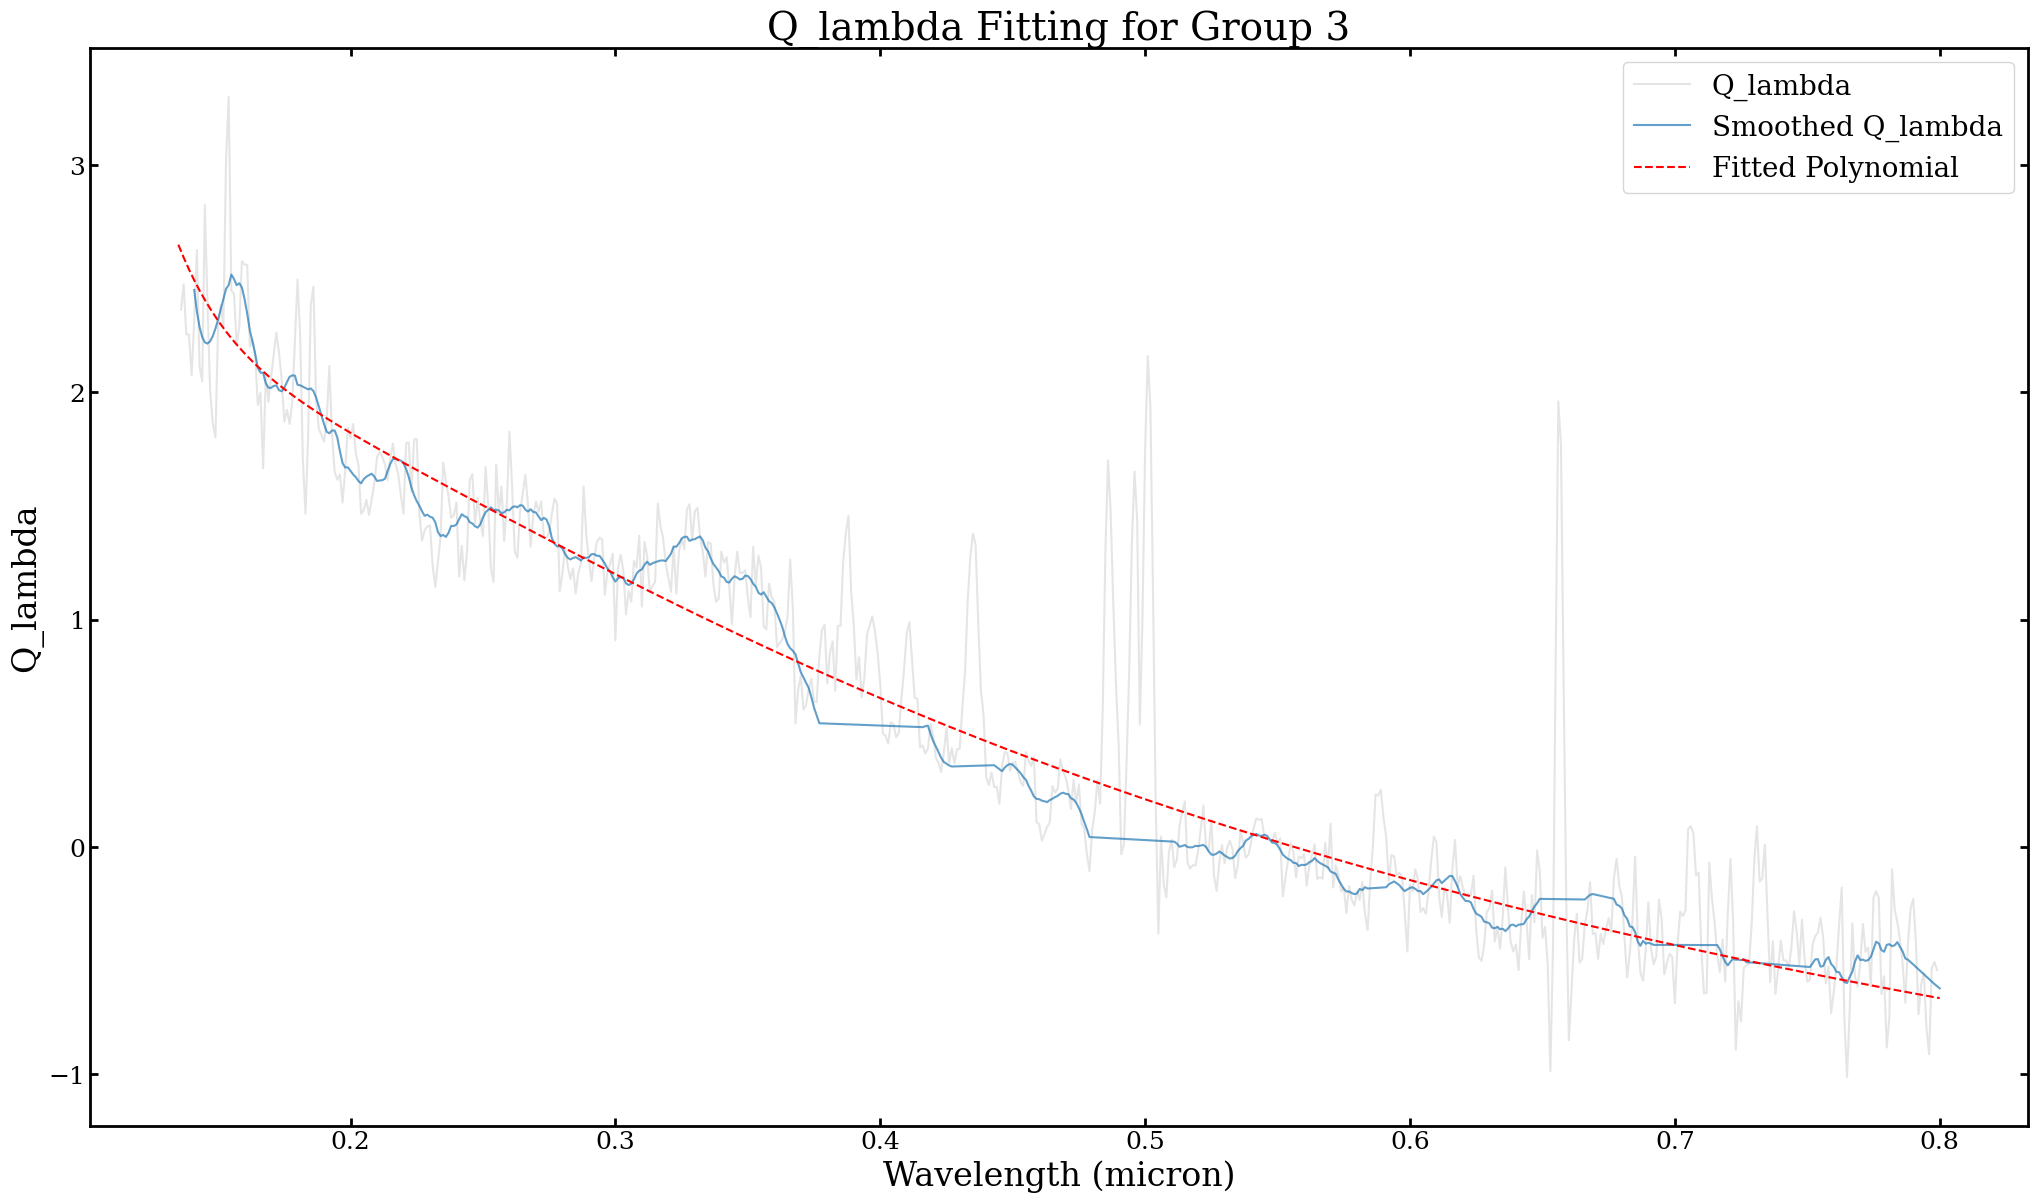

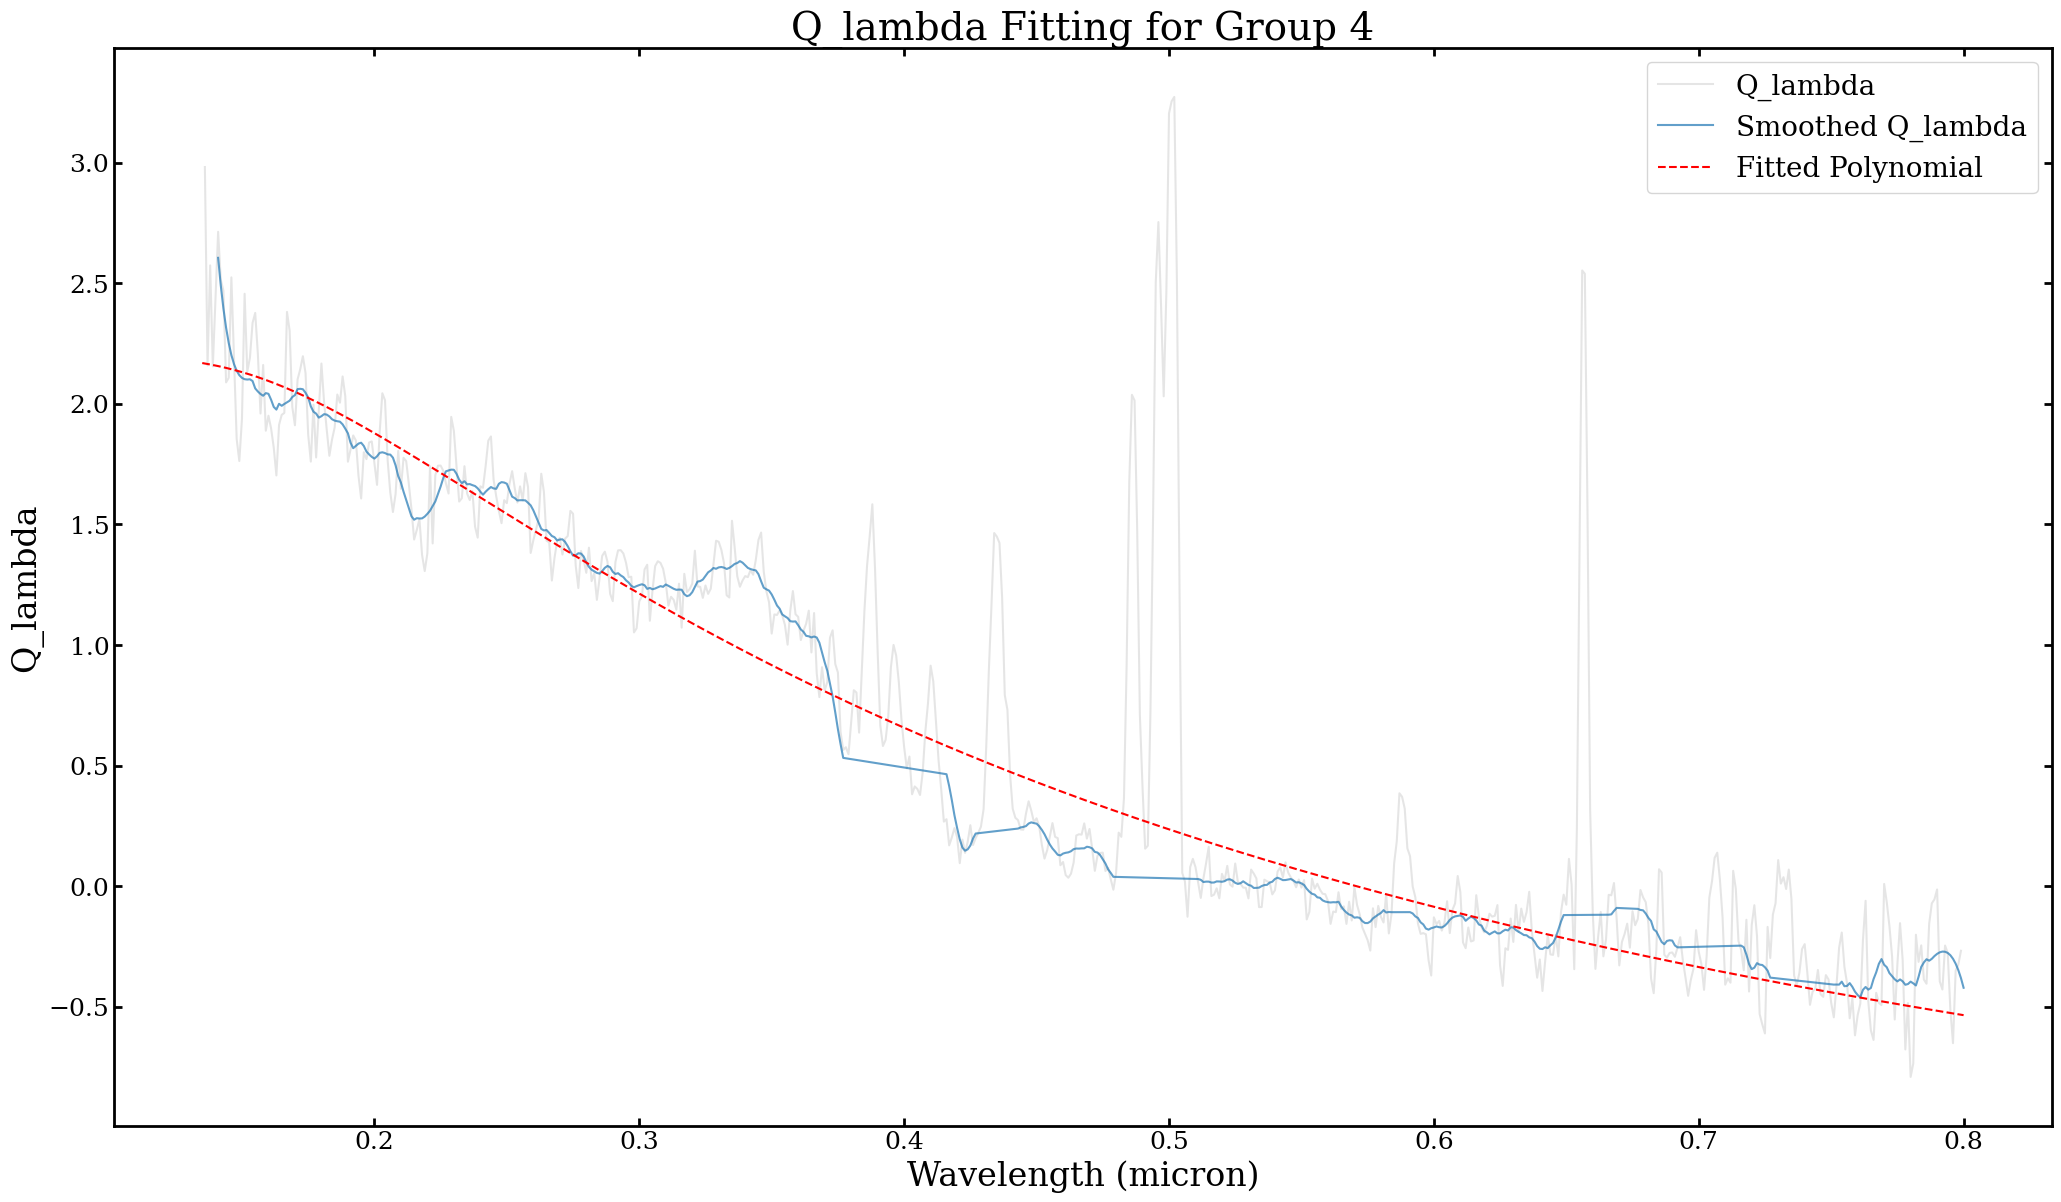

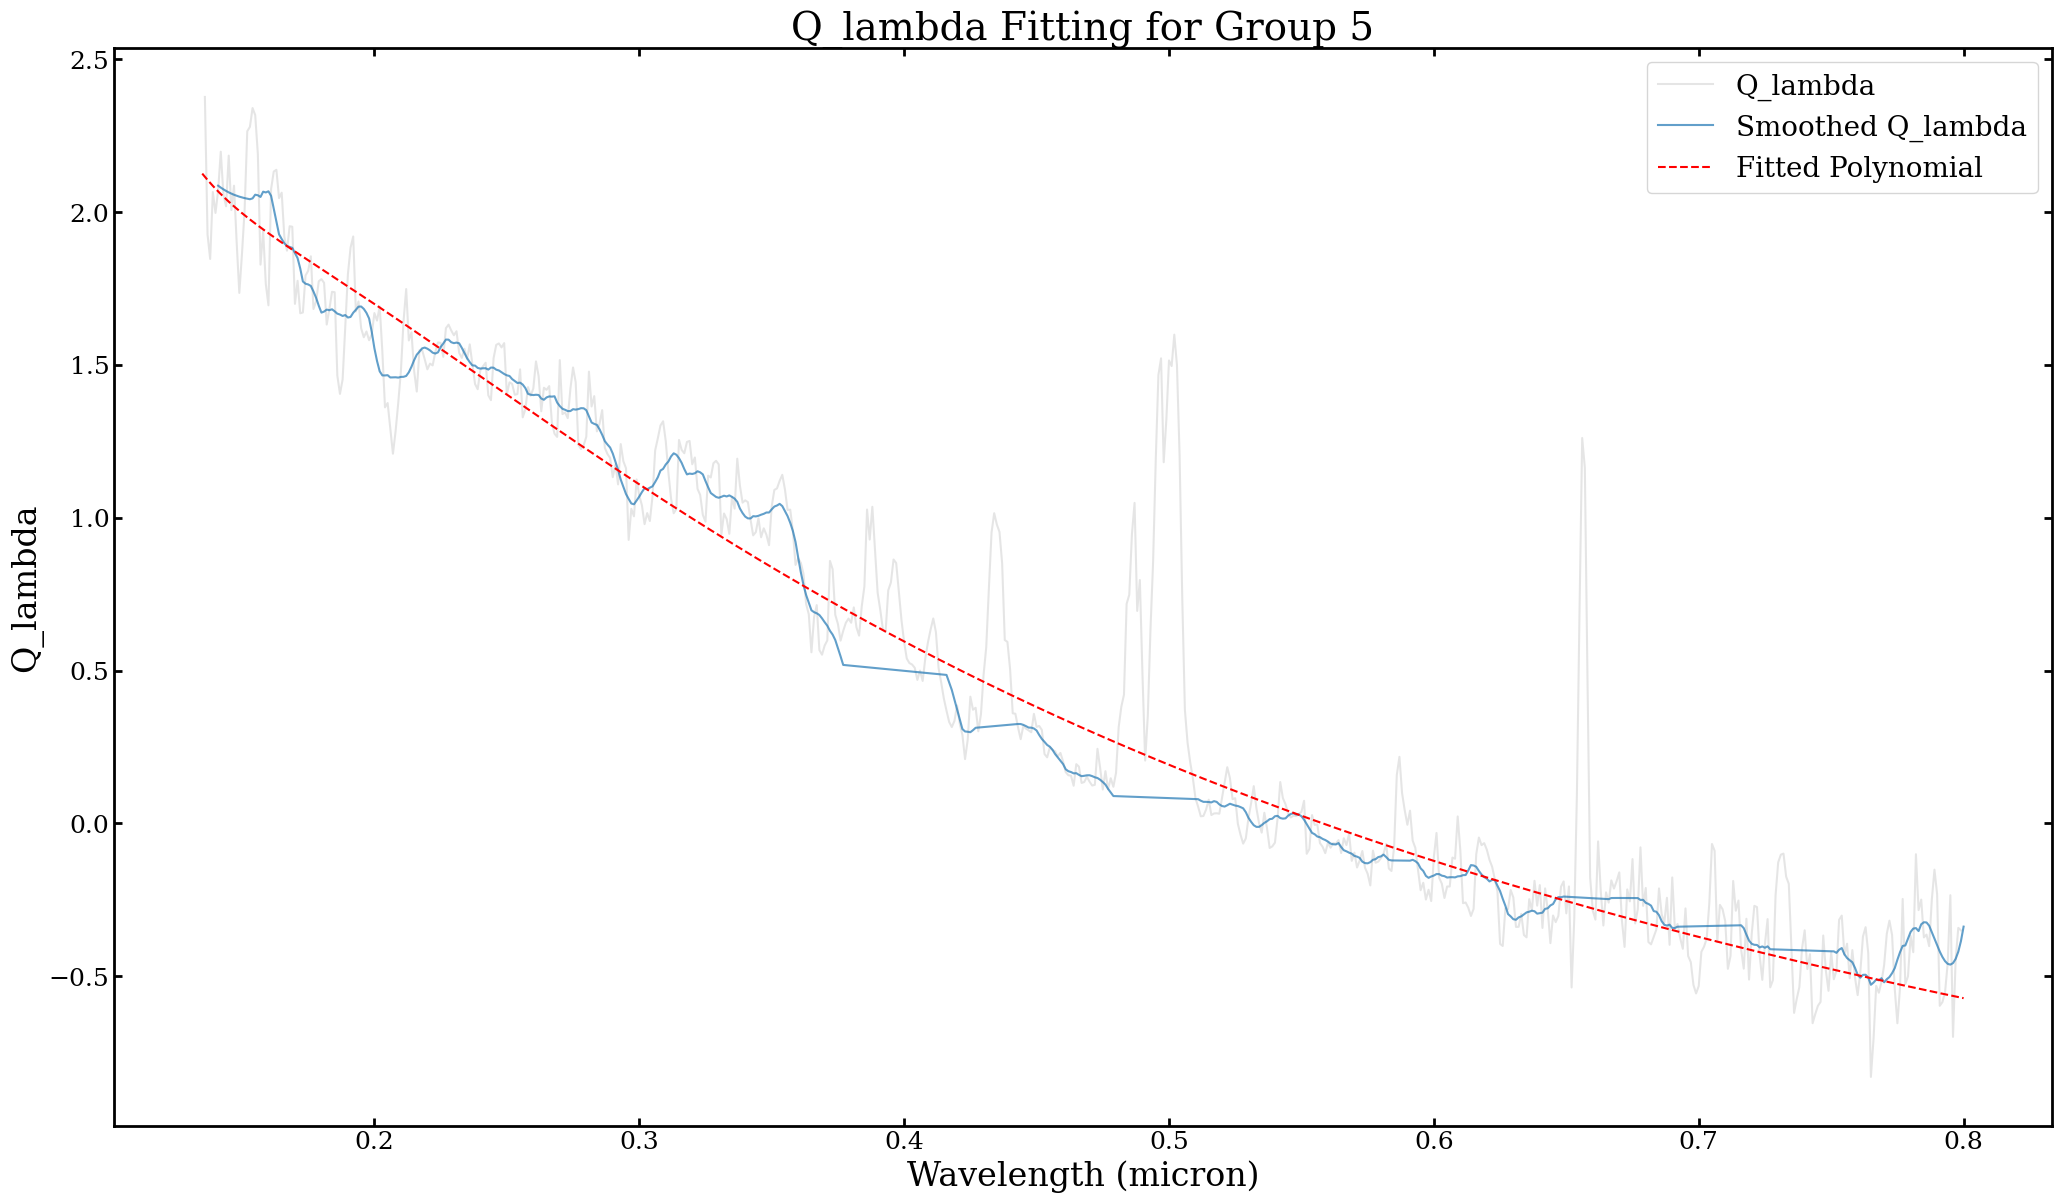

In [138]:

mask_regions = [
    (1350,1400),
    (3775,4150),
    (4280, 4425),  # Ca II H+K
    (4800, 5100),  # H-beta (4861) + [OIII] (4959, 5007) - 这是一个大包络
    (5850,5900),
    (6500, 6650),  # H-alpha (6563) + [NII]
    (6700, 6760) ,  # [SII] Doublet
    (6925,7150),
    (7275,7500),
]

window_len = 25
poly_order = 3

fig, ax = plt.subplots(figsize=(25,14))
Smoothed_Q_array=[]
Poly_Fit=[]
popts, pcovs = [], []

for i in range(Q_lambda_array.shape[0]):
    wavelengths=averager.common_wavelength/10000
    Q_lambda=Q_lambda_array[i]


    series_curve = pd.Series(Q_lambda, index=wavelengths)
    curve_clean = series_curve.replace([np.inf, -np.inf], np.nan).interpolate(method='linear', limit_direction='both')
    curve_clean = curve_clean.to_numpy()

    mask=np.ones_like(wavelengths, dtype=bool)
    for (low, high) in mask_regions:
        low, high = float(low)/10000, float(high)/10000
        mask &= ~((wavelengths >= low) & (wavelengths <= high))

    valid_data=np.isfinite(curve_clean) & np.isfinite(wavelengths) & mask

    smoothed_curve = savgol_filter(curve_clean[valid_data], window_length=window_len, polyorder=poly_order)

    subfig, subax = plt.subplots(figsize=(25,14))
    subax.plot(wavelengths,Q_lambda, color='gray', alpha=0.2,label='Q_lambda')
    subax.plot(wavelengths[valid_data], smoothed_curve, label='Smoothed Q_lambda',alpha=0.7)

    popt, pcov = scipy.optimize.curve_fit(polynomial_for_Q_fitting, wavelengths[valid_data], smoothed_curve)
    popts.append(popt)
    pcovs.append(pcov)

    fitted_curve = polynomial_for_Q_fitting(wavelengths, *popt)
    subax.plot(wavelengths, fitted_curve, color='red', linestyle='--', label='Fitted Polynomial')
    subax.set_xlabel('Wavelength (micron)', fontsize=24)
    subax.set_ylabel('Q_lambda', fontsize=24)
    subax.set_title('Q_lambda Fitting for Group '+str(i+1), fontsize=28)
    subax.legend(fontsize=20)
    print('Fitted coefficients for Group '+str(i+1)+':', popt)
    print('Function: Q = {:.4f} + {:.4f}*(1/lambda) + {:.4f}*(1/lambda)^2 + {:.4f}*(1/lambda)^3'.format(*popt))

    ax.plot(wavelengths, fitted_curve, label='Fitted Group '+str(i+1)+":"+f"{group_decrement_list[i+1]:.2f}")
    ax.plot(wavelengths, Calzetti(wavelengths), color='red', linestyle='--', label='Calzetti Curve' if i==0 else "",linewidth=4)


    Smoothed_Q_array.append(smoothed_curve)
    Smoothed_Wavelengths=wavelengths


ax.set_xlabel('Wavelength (Micron)', fontsize=24)
ax.set_ylabel('Q_lambda', fontsize=24)
ax.set_title('Polynomial Fitting of Q_lambda for Different Groups', fontsize=28)

Smoothed_Q_array=np.array(Smoothed_Q_array)
Final_Q_array=np.average(Smoothed_Q_array[1:], weights=[group_decrement_list[i]-group_decrement_list[0] for i in range(2,6)], axis=0)


ax.plot(Smoothed_Wavelengths[valid_data], Final_Q_array, color='blue', linestyle='-', label='Final Average Q_lambda',alpha=0.5)

popt, pcov = scipy.optimize.curve_fit(polynomial_for_Q_fitting, Smoothed_Wavelengths[valid_data], Final_Q_array)
fitted_final_curve = polynomial_for_Q_fitting(Smoothed_Wavelengths, *popt)
ax.plot(Smoothed_Wavelengths, fitted_final_curve, color='green', label='Fitted Final Curve',linewidth=4)
ax.set_xlim(0.12,0.85)
ax.legend(fontsize=20)
plt.show()


In [117]:
import pandas as pd
coefficients_table = pd.DataFrame(np.array(popts), columns=['a0', 'a1', 'a2', 'a3'])
coefficients_table.index = [f'Group {i+1}' for i in range(len(popts))]
coefficients_table.loc['Final Average'] = popt
coefficients_table = coefficients_table.round(4)

print("Q=a0 + a1*(1/lambda) + a2*(1/lambda)^2 + a3*(1/lambda)^3")
coefficients_table

Q=a0 + a1*(1/lambda) + a2*(1/lambda)^2 + a3*(1/lambda)^3


,a0,a1,a2,a3
Group 1,-3.7076,2.3594,-0.2476,0.0061
Group 2,-2.7235,1.9438,-0.2871,0.0168
Group 3,-2.7102,2.0024,-0.3087,0.0180
Group 4,-2.3887,1.7599,-0.2475,0.0131
Group 5,-2.3499,1.7055,-0.2425,0.0127
Final Average,-2.4766,1.8079,-0.2623,0.0143


In [121]:
delta=polynomial_for_Q_fitting(4400/10000, *popt)-polynomial_for_Q_fitting(5500/10000, *popt)
normalization_factor_for_BV=1/delta
normalization_factor_for_BV

np.float64(2.4034304147158503)

In [123]:
normalization_factor_for_BV*popt[0]

np.float64(-5.952283460091378)